## XGBoost

XGBoost is classification model that integrates key concept in classification: regularization, boosting, decision trees, gradient descent (in particular not stopping to the first derivative but using the second derivative to tune parameters with the objective of finding the minimum with utmost accuracy) and subsampling. All this together provides a model that tries to solve key problem in this field, like overfitting, accuracy and computational complexity. This is also true for the use of special data structures that assure better performances.

In [ ]:
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt
import xgboost as xgb
import catboost as cb
import shap
import optuna
import math
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, auc
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
! pip install xgboost


In [ ]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00


In [ ]:
! pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
! pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 6.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



In [ ]:
def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",", names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
    ])
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.iloc[:, 0:10].values # Get first two columns as the input
    Y = data_train.iloc[:, 10].values # Get the third column as the label
    Y[Y=="g"]=1
    Y[Y=="h"]=0
    Y = Y.astype(int)
    return X,Y



# Load the dataset
X, Y = load_dataset("https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data")


# Division between test and train dataset
rng = rnd.Random(42)
idx = list(range(X.shape[0]))
test_idx = rng.sample(idx, int(X.shape[0]*0.25))
train_idx = [i for i in idx if i not in test_idx]
X_training = X[train_idx]
X_test  = X[test_idx]
Y_training = Y[train_idx]
Y_test  = Y[test_idx]

# Validation set definition
idx = list(range(X_training.shape[0]))
val_idx = rng.sample(idx, int(X_training.shape[0]*0.25))
train_idx = [i for i in idx if i not in val_idx]
X_val  = X_training[val_idx]
X_training = X_training[train_idx]
Y_val  = Y_training[val_idx]
Y_training = Y_training[train_idx]

ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)

The parameters involved in this model are:
     - max_depth: since we are creating a boosted solution using tree as the base model, this parameter regulates the maximum depth of the trees used <br>
     - min_child_weight: parameter to regulate the minimum amount of point needed to add another node to the decision tree, regulates overfitting by
                         avoiding to split over very small group of points <br>
     - learning rate: moltiplicative coefficient used to regulate the stepping size in the gradient descent, together with the optimal coefficient<br>
                      obtained help regulate both the number of iteration needed to converge and the accuracy of the final solution<br>
     - n_estimators: number of total trees used in the boosted solution<br>
     - subsample and colsample_bytree: perctage of data or of columns used by each tree, with a similar concept used in random forest with bagging<br>
     - gamma: parameter to regulate the pruning, with an high value the code will favor a simplier solution rather then a slightly more accurate one<br>
     - lambda: parameter to regulate model complexity

In [ ]:
ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)

# Parameters configuration
model = xgb.XGBClassifier(
    booster="gbtree",            # weak learner used as a base
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,                 # depth of trees
    subsample=0.8,               # 80% of rows
    colsample_bytree=0.8,        # 80% of columns
    scale_pos_weight=ratio,      # parameter that accounts for the inbalance of classes
    objective='binary:logistic', # goal of the model
    n_jobs=-1,                   # uses all cpu cores
    eval_metric='auc',           # metric used
    early_stopping_rounds=50,    # Number of iteration that takes to stop if there are no significant imporvments
    tree_method="hist",
    enable_categorical=True
)

# Training
print("Inizio addestramento...")

model.fit(
    X_training, Y_training,
    eval_set=[(X_training, Y_training), (X_val, Y_val)],
    verbose=100
)

# Evaluation
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("Classification Report")
print(classification_report(Y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(Y_test, y_prob):.4f}")



Inizio addestramento...
[0]	validation_0-auc:0.86937	validation_1-auc:0.85480
[100]	validation_0-auc:0.94841	validation_1-auc:0.92809
[200]	validation_0-auc:0.96473	validation_1-auc:0.93396
[300]	validation_0-auc:0.97523	validation_1-auc:0.93702
[400]	validation_0-auc:0.98214	validation_1-auc:0.93797
[500]	validation_0-auc:0.98728	validation_1-auc:0.93850
[541]	validation_0-auc:0.98907	validation_1-auc:0.93864
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1696
           1       0.90      0.91      0.90      3059

    accuracy                           0.88      4755
   macro avg       0.87      0.86      0.87      4755
weighted avg       0.88      0.88      0.88      4755

ROC AUC Score: 0.9381


## Performance analysis for different parameters

Analysis with ROC-AUC metric of XGBoost parameters

In [ ]:
# Base parameters
base_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'verbosity': 0,
    # Defaults for parameters we aren't testing
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

# Parameters to analyze
params_to_test = {
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'n_estimators': [100, 300, 500, 800, 1000]
}


results = {} # To store the results

# setting up optimized library for K folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        # Update params
        current_params = base_params.copy()
        current_params[param_name] = value        # uses default parameters for the rest and changes only one parameter

        # Train & CV
        model = xgb.XGBClassifier(**current_params)
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    # Save data for plotting
    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")


# Calculate grid size
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows)) #fix window to fit the plots
fig.suptitle('XGBoost Hyperparameter Performance Analysis (5-Fold CV)', fontsize=20)
axes = axes.flatten() # Flatten 2D array to 1D for easy iteration

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]

    # Extract data
    x_vals = data['values']
    y_means = data['means']
    y_errs = data['stds']

    # Plot Error Bar
    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='royalblue', ecolor='lightgray', elinewidth=2, markeredgecolor='navy')

    # Styling
    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean ROC AUC', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the max value
    max_idx = np.argmax(y_means)
    ax.annotate(f'Max: {y_means[max_idx]:.4f}',
                xy=(x_vals[max_idx], y_means[max_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='green', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit title
plt.show()


# TRAINING ON BEST FOUND PARAMETERS
print("FINAL ANALYSIS: COMBINING BEST PARAMETERS")

# Extract best parameters automatically from results
best_found_params = base_params.copy() # Start with base defaults

print("Best parameters found individually:")
for param_name, data in results.items():
    # Find index of maximum Mean AUC
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_score = data['means'][best_idx]

    # Update the best params dictionary
    best_found_params[param_name] = best_value

    print(f"  - {param_name}: {best_value} (AUC: {best_score:.4f})")

print("\nFull configuration for final model:")
print(best_found_params)

# Train on the WHOLE dataset (Production Ready)
print("\nTraining final model on full dataset...")

final_model = xgb.XGBClassifier(**best_found_params)
final_model.fit(X_training, Y_training)


# Final Evaluation on Test Set
print("FINAL TEST SET PERFORMANCE")

# Final predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Calculate accuracy for more clear results
acc_final = accuracy_score(Y_test, y_pred_final)
zero_one_loss_final = 1 - acc_final

# Final AUC score for comparison
auc_final = roc_auc_score(Y_test, y_prob_final)

print(f"Final Test ROC AUC:  {auc_final:.4f}")
print(f"Final Test Accuracy: {acc_final:.4f}")
print(f"Final Test 0-1 Loss: {zero_one_loss_final:.4f} (Error Rate)")

# Number of missclassified events
n_errors = int(zero_one_loss_final * len(Y_test))
print(f"\nTotal misclassified samples: {n_errors} out of {len(Y_test)}")




NameError: name 'ratio' is not defined

Same hyperparameter study using basic 0-1 loss metric

In [ ]:
# Base parameters (fixed)
base_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

# Parameters to analyze
params_to_test = {
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'n_estimators': [100, 300, 500, 800, 1000]
}


results = {}
# K Fold setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Analysis (Metric: 0-1 Loss)...")
# loop to change one parameter at the time, keeping standard values for the others
for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        model = xgb.XGBClassifier(**current_params)

        # Changed auc score to accuracy score also for parameter analysis
        scores_acc = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='accuracy')
        scores_error = 1 - scores_acc

        means.append(scores_error.mean())
        stds.append(scores_error.std())

    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")


n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('XGBoost Hyperparameter Analysis (Metric: 0-1 Loss)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    x_vals = data['values']
    y_means = data['means'] # 0-1 loss
    y_errs = data['stds']

    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='firebrick', ecolor='lightgray', elinewidth=2, markeredgecolor='darkred')

    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean 0-1 Loss (Lower is Better)', fontsize=10) # Label aggiornata
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the minumum value
    min_idx = np.argmin(y_means)
    ax.annotate(f'Min Loss: {y_means[min_idx]:.4f}',
                xy=(x_vals[min_idx], y_means[min_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='green', fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Training the whole dataset on the best found parameters and verify the performance
print("FINAL ANALYSIS: COMBINING BEST PARAMETERS (Minimizing 0-1 Loss)")

best_found_params = base_params.copy()

print("Best parameters found individually (Lowest Error):")
for param_name, data in results.items():
    best_idx = np.argmin(data['means'])
    best_value = data['values'][best_idx]
    best_score = data['means'][best_idx]

    best_found_params[param_name] = best_value

    print(f"  - {param_name}: {best_value} (Loss: {best_score:.4f})")

print("\nFull configuration for final model:")
print(best_found_params)

# Verify Performance
print("\nVerifying combined performance with Cross-Validation...")


# rain on WHOLE dataset
print("\nTraining final model on full dataset...")
final_model = xgb.XGBClassifier(**best_found_params)
final_model.fit(X_training, Y_training)

# Final predictions
y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

# Calculate accuracy for more clear results
acc_final = accuracy_score(Y_test, y_pred_final)
zero_one_loss_final = 1 - acc_final

# Final AUC score for comparison
auc_final = roc_auc_score(Y_test, y_prob_final)

print(f"Final Test ROC AUC:  {auc_final:.4f}")
print(f"Final Test Accuracy: {acc_final:.4f}")
print(f"Final Test 0-1 Loss: {zero_one_loss_final:.4f} (Error Rate)")


NameError: name 'ratio' is not defined

## Ottimizzazione con Optuna

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'n_jobs': -1,
        'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'verbosity': 0,

        # Define grid search
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 100, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
    }


    xgb_model = xgb.XGBClassifier(**param_space, random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(xgb_model, X_training, Y_training, cv=cv, scoring='roc_auc').mean()

    return score

# Study execution
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Final results
print("\nParametri migliori trovati da Optuna:")
print(study.best_params)

# best found parameters
final_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'random_state': 42,
    **study.best_params
}

best_model_optuna = xgb.XGBClassifier(**final_params)
best_model_optuna.fit(X_training, Y_training)

# Test set evaluation
y_pred_opt = best_model_optuna.predict(X_test)
y_prob_opt = best_model_optuna.predict_proba(X_test)[:, 1]

auc_opt = roc_auc_score(Y_test, y_prob_opt)
acc_opt = accuracy_score(Y_test, y_pred_opt)
loss_01 = 1 - acc_opt

print(f"ROC AUC Score: {auc_opt:.4f}")
print(f"Accuracy Score: {acc_opt:.4f}")
print(f"0-1 Mean Loss: {loss_01:.4f}")

[I 2026-02-06 13:03:11,934] A new study created in memory with name: no-name-20da3d94-7996-4945-830f-b04ba5ca4b6d
[I 2026-02-06 13:03:13,813] Trial 0 finished with value: 0.926952011747278 and parameters: {'gamma': 3.3284539512188838, 'reg_lambda': 2.3529670739213873, 'learning_rate': 0.11009326854855533, 'subsample': 0.9543197939764514, 'colsample_bytree': 0.7408560876314547, 'max_depth': 7, 'n_estimators': 349}. Best is trial 0 with value: 0.926952011747278.
[I 2026-02-06 13:03:19,172] Trial 1 finished with value: 0.9235885494464181 and parameters: {'gamma': 3.59672543028681, 'reg_lambda': 25.306786387205392, 'learning_rate': 0.1397225576590703, 'subsample': 0.9201548791603381, 'colsample_bytree': 0.9431973281463232, 'max_depth': 10, 'n_estimators': 993}. Best is trial 0 with value: 0.926952011747278.
[I 2026-02-06 13:03:22,276] Trial 2 finished with value: 0.9230337741031123 and parameters: {'gamma': 2.07586699449409, 'reg_lambda': 46.03998519377983, 'learning_rate': 0.0340841933511


Parametri migliori trovati da Optuna:
{'gamma': 1.2088656287289261, 'reg_lambda': 0.8177710156180247, 'learning_rate': 0.04674816133266195, 'subsample': 0.7156255101857467, 'colsample_bytree': 0.7502490935025544, 'max_depth': 7, 'n_estimators': 802}

PERFORMANCE FINALE (TEST SET)
ROC AUC Score: 0.9338
Accuracy Score: 0.8801
0-1 Mean Loss: 0.1199
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1711
           1       0.90      0.91      0.91      3044

    accuracy                           0.88      4755
   macro avg       0.87      0.87      0.87      4755
weighted avg       0.88      0.88      0.88      4755



# CatBoost

Hyperparameter study with ROC-AUC metric for CatBoost

Testing depth... Done.
Testing learning_rate... Done.
Testing l2_leaf_reg... Done.
Testing iterations... Done.
Testing random_strength... Done.
Testing bagging_temperature... Done.


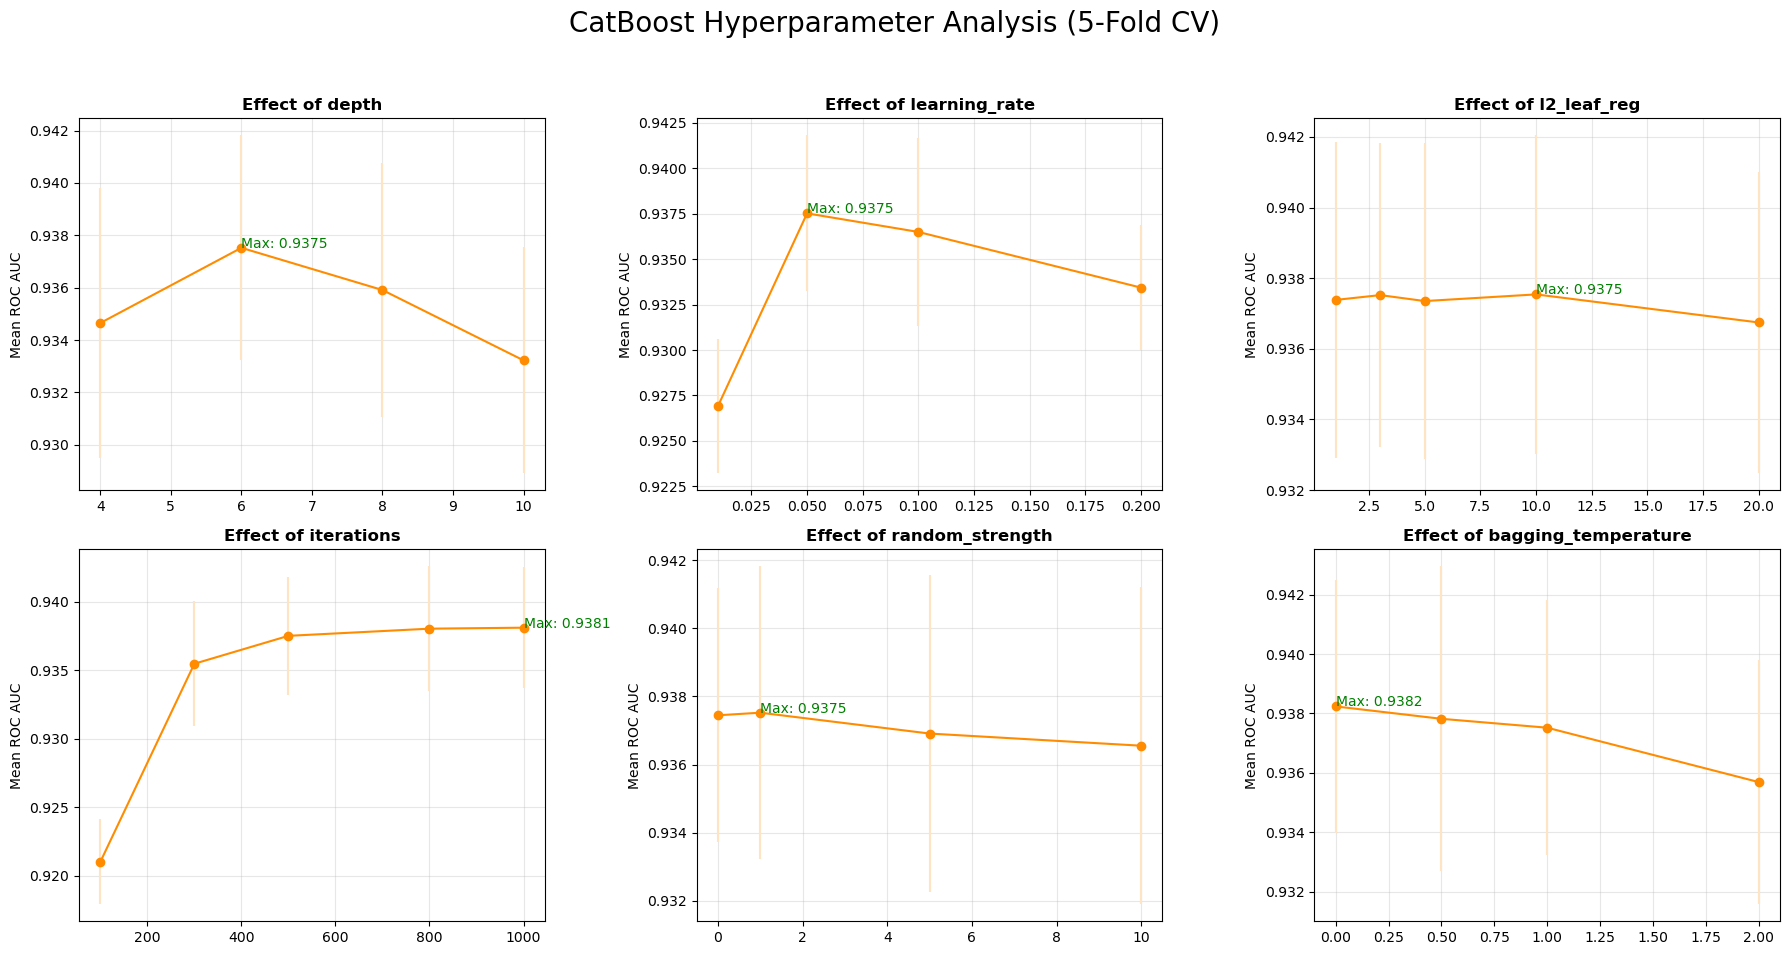

COMBINING BEST PARAMETERS FOR CATBOOST
 - depth: 6
 - learning_rate: 0.05
 - l2_leaf_reg: 10
 - iterations: 1000
 - random_strength: 1
 - bagging_temperature: 0
EVALUATING FINAL COMBINED MODEL...

RESULTS (5-Fold CV):


AttributeError: 'CatBoostClassifier' object has no attribute 'mean'

In [ ]:
base_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    # Defaults
    'iterations': 500,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 3,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 1,
    'random_strength': 1    # Adding noise to splits to avoid overfitting
}

# Parameters to analyze
params_to_test = {
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 10, 20],
    'iterations': [100, 300, 500, 800, 1000],
    'random_strength': [0, 1, 5, 10],
    'bagging_temperature': [0, 0.5, 1, 2]
}

results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        # Initialize CatBoostClassifier
        model = cb.CatBoostClassifier(**current_params)

        # Cross Validation
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    results[param_name] = {'values': param_values, 'means': means, 'stds': stds}
    print("Done.")

# PLots
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('CatBoost Hyperparameter Analysis (5-Fold CV)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    ax.errorbar(data['values'], data['means'], yerr=data['stds'], fmt='-o', color='darkorange', ecolor='bisque')
    ax.set_title(f'Effect of {param_name}', fontweight='bold')
    ax.set_ylabel('Mean ROC AUC')
    ax.grid(True, alpha=0.3)

    max_idx = np.argmax(data['means'])
    ax.annotate(f"Max: {data['means'][max_idx]:.4f}",
                xy=(data['values'][max_idx], data['means'][max_idx]), color='green')

for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Final training
print("COMBINING BEST PARAMETERS FOR CATBOOST")

best_found_params = base_params.copy()

for param_name, data in results.items():
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_found_params[param_name] = best_value
    print(f" - {param_name}: {best_value}")


# Initialize the final model architecture
final_model_eval = cb.CatBoostClassifier(**best_found_params)
final_model_eval.fit(X_training,Y_training)
cat_bestpar= best_found_params.copy()
y_pred = final_model_eval.predict(X_test)
test_acc = accuracy_score(Y_test, y_pred)

print(f"\nRESULTS (5-Fold CV):")
print(f"Final Mean Accuracy: {test_acc:.2f}%")



CatBoost hyper-parameter study with OPTUNA

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'verbose': False,
        'random_seed': 42,

        # Parameters to optimize
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        'bootstrap_type': 'Bayesian',
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),

        'scale_pos_weight': ratio
    }

    # model setup
    model = cb.CatBoostClassifier(**param_space)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # K fold score
    score = cross_val_score(model, X_training, Y_training, cv=cv, scoring='roc_auc').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\nMigliori parametri CatBoost:")
print(study.best_params)

# Training on whole set
final_model_cb = cb.CatBoostClassifier(**study.best_params, verbose=False, random_seed=42, scale_pos_weight=ratio)
final_model_cb.fit(X_training, Y_training)

# Test set evaluation
y_pred = final_model_cb.predict(X_test)
y_prob = final_model_cb.predict_proba(X_test)[:, 1]

print(f"PERFORMANCE FINALE CATBOOST (TEST SET)")
print(f"ROC AUC:  {roc_auc_score(Y_test, y_prob):.4f}")
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"0-1 Loss: {1 - accuracy_score(Y_test, y_pred):.4f}")

[I 2026-02-06 13:24:18,436] A new study created in memory with name: no-name-0cd4ade7-018b-4094-8115-a5bb809b028e
[I 2026-02-06 13:26:41,723] Trial 0 finished with value: 0.9276859551118605 and parameters: {'iterations': 606, 'learning_rate': 0.018193468813768633, 'depth': 10, 'l2_leaf_reg': 8.582271883286163, 'random_strength': 2.1009715152939155, 'bagging_temperature': 1.9004131487730485}. Best is trial 0 with value: 0.9276859551118605.
[I 2026-02-06 13:27:09,025] Trial 1 finished with value: 0.9279881146895859 and parameters: {'iterations': 756, 'learning_rate': 0.02327491242132695, 'depth': 6, 'l2_leaf_reg': 7.047070725567276, 'random_strength': 4.092267945124916, 'bagging_temperature': 4.536306367381528}. Best is trial 1 with value: 0.9279881146895859.
[I 2026-02-06 13:27:29,176] Trial 2 finished with value: 0.9346186490589152 and parameters: {'iterations': 473, 'learning_rate': 0.12316430411751433, 'depth': 7, 'l2_leaf_reg': 19.415629330781655, 'random_strength': 0.45538227219090


Migliori parametri CatBoost:
{'iterations': 433, 'learning_rate': 0.15806827694855796, 'depth': 5, 'l2_leaf_reg': 11.950018521337322, 'random_strength': 7.069373735980409, 'bagging_temperature': 0.7591677473342178}

PERFORMANCE FINALE CATBOOST (TEST SET)
ROC AUC:  0.9352
Accuracy: 0.8814
0-1 Loss: 0.1186


# Gradient Boost

Standard gradient boost parameter study

Starting Gradient Boosting Analysis (Metric: 0-1 Loss)...
Testing learning_rate... Done.
Testing n_estimators... Done.
Testing max_depth... Done.
Testing subsample... Done.
Testing max_features... Done.
Testing min_samples_split... Done.


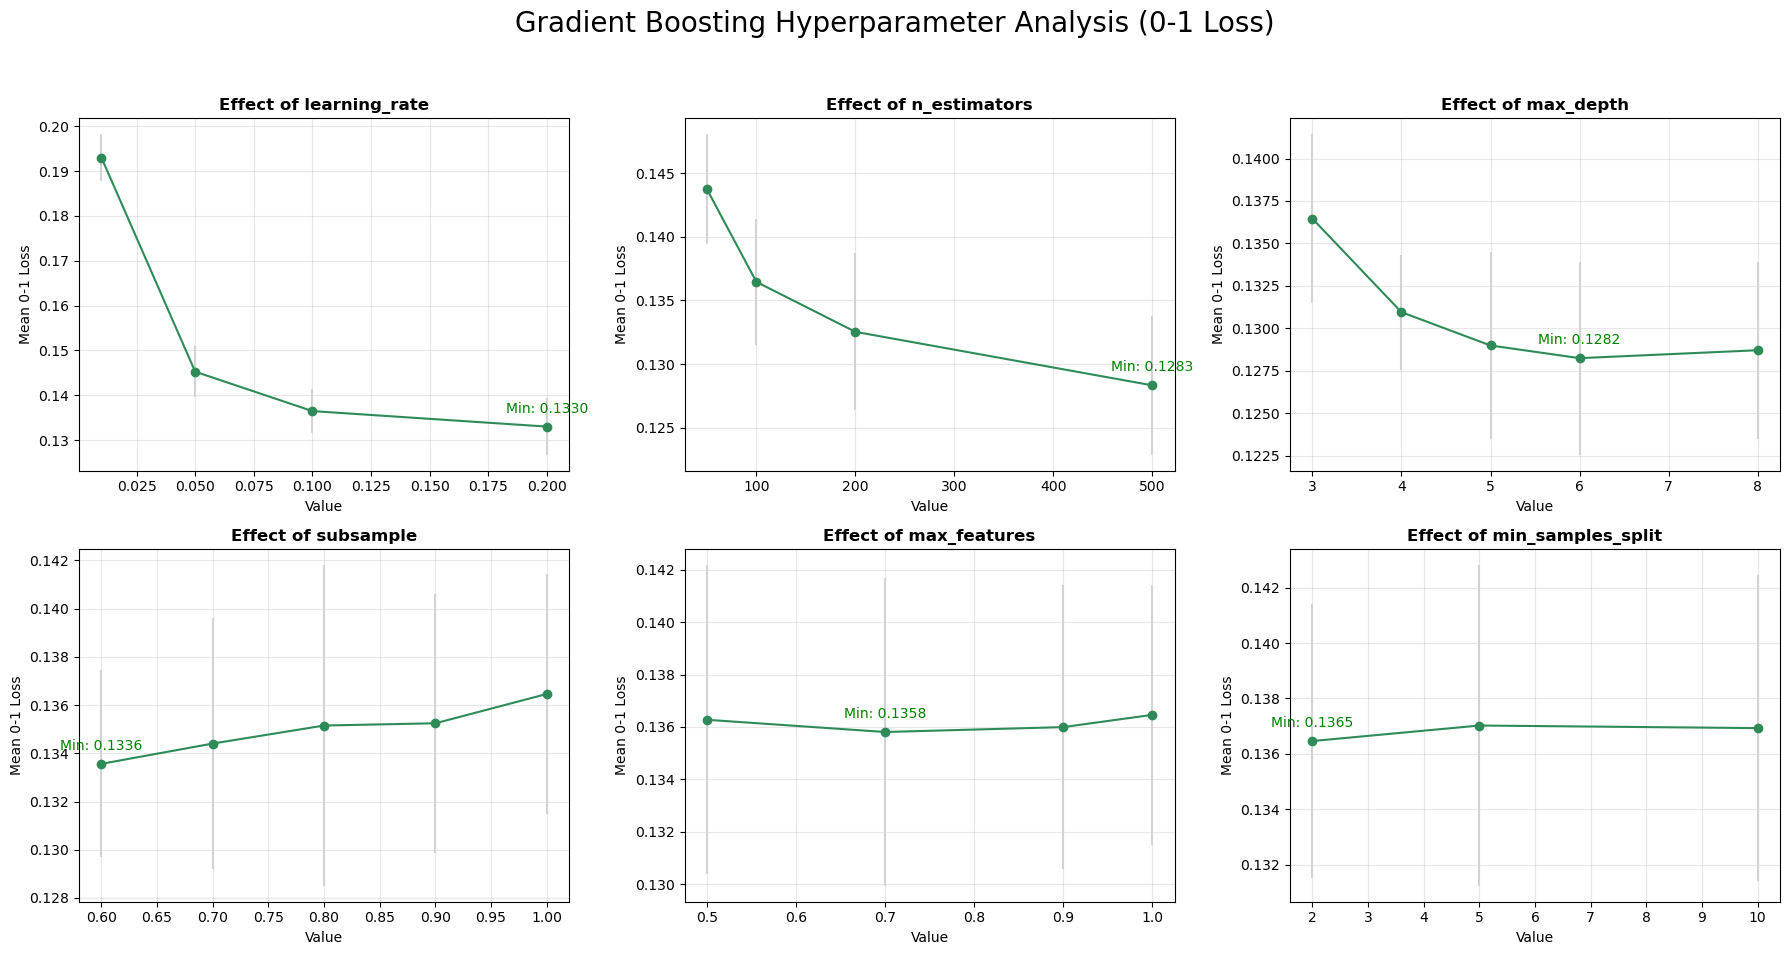


COMBINING BEST PARAMETERS FOR GRADIENT BOOSTING
 - learning_rate: 0.2
 - n_estimators: 500
 - max_depth: 6
 - subsample: 0.6
 - max_features: 0.7
 - min_samples_split: 2

FINAL TEST PERFORMANCE
Accuracy: 0.8848
0-1 Loss: 0.1152


In [ ]:

base_params = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

# Parameters to test
params_to_test = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_features': [0.5, 0.7, 0.9, 1.0],
    'min_samples_split': [2, 5, 10]
}


results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        current_params = base_params.copy()
        current_params[param_name] = value

        model = GradientBoostingClassifier(**current_params)

        # 0-1 loss
        scores_acc = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='accuracy')
        scores_error = 1 - scores_acc

        means.append(scores_error.mean())
        stds.append(scores_error.std())

    results[param_name] = {'values': param_values, 'means': means, 'stds': stds}
    print("Done.")
# Plot
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
fig.suptitle('Gradient Boosting Hyperparameter Analysis (0-1 Loss)', fontsize=20)
axes = axes.flatten()

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]
    ax.errorbar(data['values'], data['means'], yerr=data['stds'], fmt='-o', color='seagreen', ecolor='lightgray')
    ax.set_title(f'Effect of {param_name}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Mean 0-1 Loss')
    ax.grid(True, alpha=0.3)

    min_idx = np.argmin(data['means'])
    ax.annotate(f'Min: {data['means'][min_idx]:.4f}',
                xy=(data['values'][min_idx], data['means'][min_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center', color='green')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Final training
print("\nCOMBINING BEST PARAMETERS FOR GRADIENT BOOSTING")
best_params_final = base_params.copy()

for param_name, data in results.items():
    best_idx = np.argmin(data['means'])
    best_params_final[param_name] = data['values'][best_idx]
    print(f" - {param_name}: {data['values'][best_idx]}")

# Final training
final_model_gb = GradientBoostingClassifier(**best_params_final)
final_model_gb.fit(X_training, Y_training)
gb_bestparams= best_params_final.copy()
# Evaluation on Test Set
y_pred = final_model_gb.predict(X_test)
test_acc = accuracy_score(Y_test, y_pred)
print(f"FINAL TEST PERFORMANCE")
print(f"Accuracy: {test_acc:.4f}")
print(f"0-1 Loss: {1 - test_acc:.4f}")

Hyper-parameter study with OPTUNA

# Analysis of simultaneously missclassified points

C:\Users\matte\anaconda3_2\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


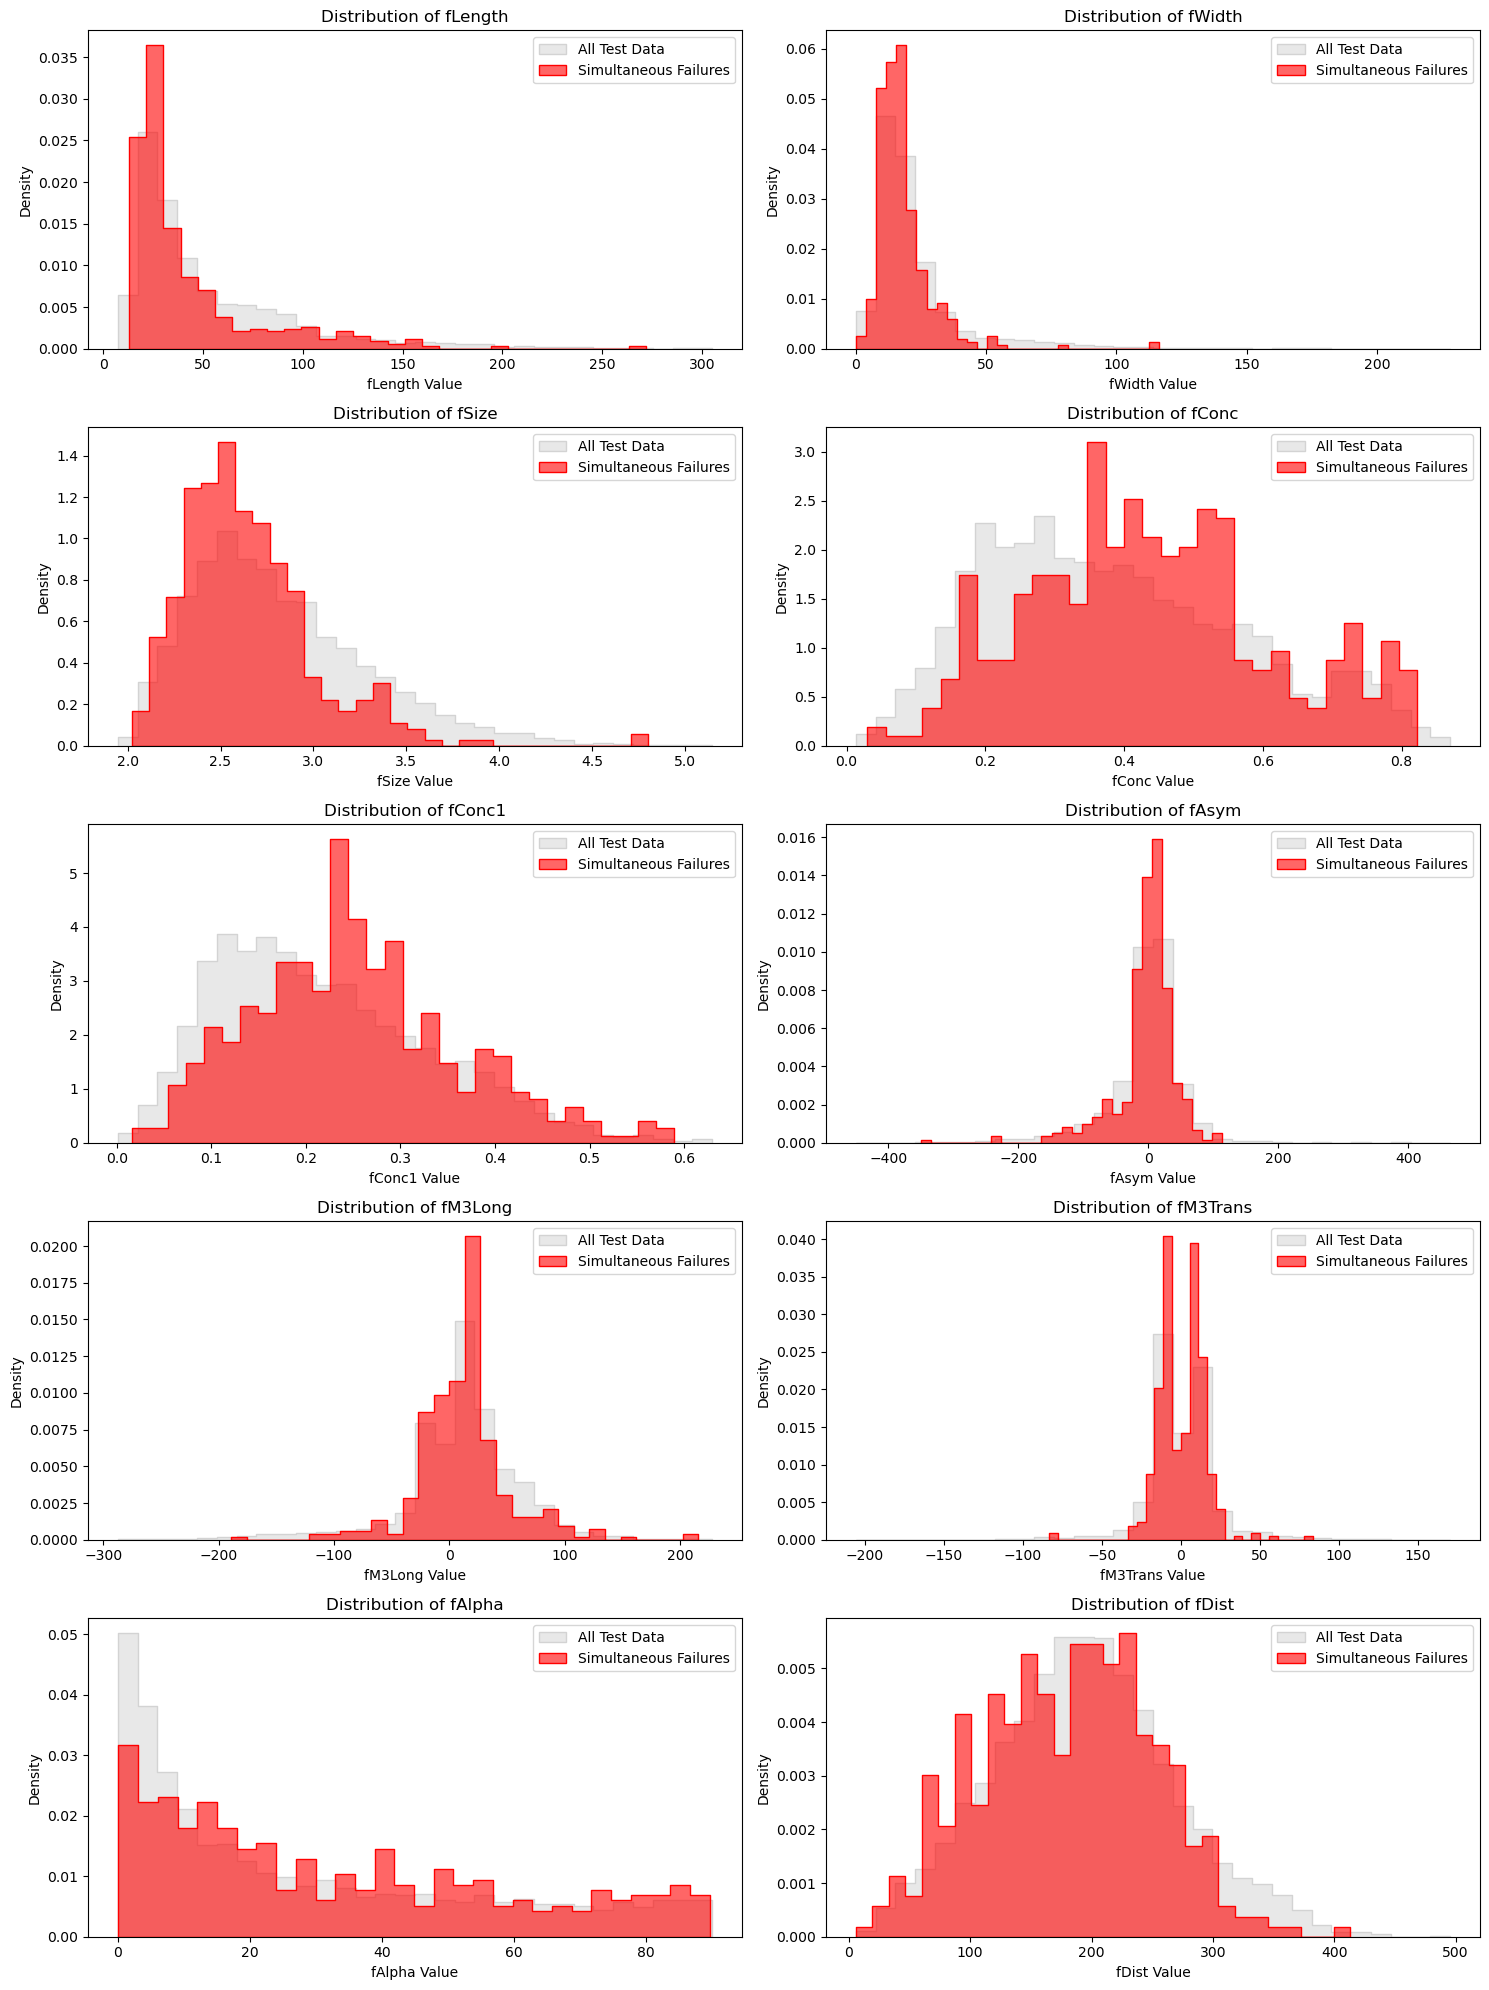

In [ ]:

feature_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist'
]

# Convert X_test to DataFrame
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test, columns=feature_names)

def get_simultaneous_failures(models_dict, X_test, y_test):
    # Prepare results table
    results = pd.DataFrame({'actual': y_test}, index=X_test.index)

    # Collect predictions
    for name, model in models_dict.items():
        results[name] = model.predict(X_test)

    # Identify rows where EVERY model was wrong
    failed_mask = True
    for name in models_dict.keys():
        failed_mask = failed_mask & (results[name] != results['actual'])

    # Combine feature data with prediction metadata
    failure_df = pd.concat([X_test.loc[failed_mask], results.loc[failed_mask]], axis=1)
    return failure_df

# Run the analysis
models = {
    'xgb': final_model,
    'cat': final_model_cb,
    'gradient_boost': final_model_gb
}

df_failures = get_simultaneous_failures(models, X_test, Y_test)

if not df_failures.empty:

    # Set up the subplot grid
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 20))
    axes = axes.flatten()

    for i, col in enumerate(feature_names):
        ax = axes[i]

        # Plot 1: The Total Population (Gray/Blue)
        sns.histplot(X_test[col], ax=ax, color='lightgray', label='All Test Data',
                     stat="density", element="step", alpha=0.5, bins=30)

        # Plot 2: The Failures
        sns.histplot(df_failures[col], ax=ax, color='red', label='Simultaneous Failures',
                     stat="density", element="step", alpha=0.6, bins=30)

        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(f"{col} Value")
        ax.set_ylabel("Density")
        ax.legend()

    plt.tight_layout()
    plt.show()

else:
    print("No shared failures found.")

# Sensibility to noise

In this section I will analyze how different are the results with the introduction of noise to different features in the dataset. </br>
The analysis will start from a simple verification that the models in use are in fact OAROS and will move to an analysis of the difference gotten by introducing different level of noise to the dataset.

## OAROS

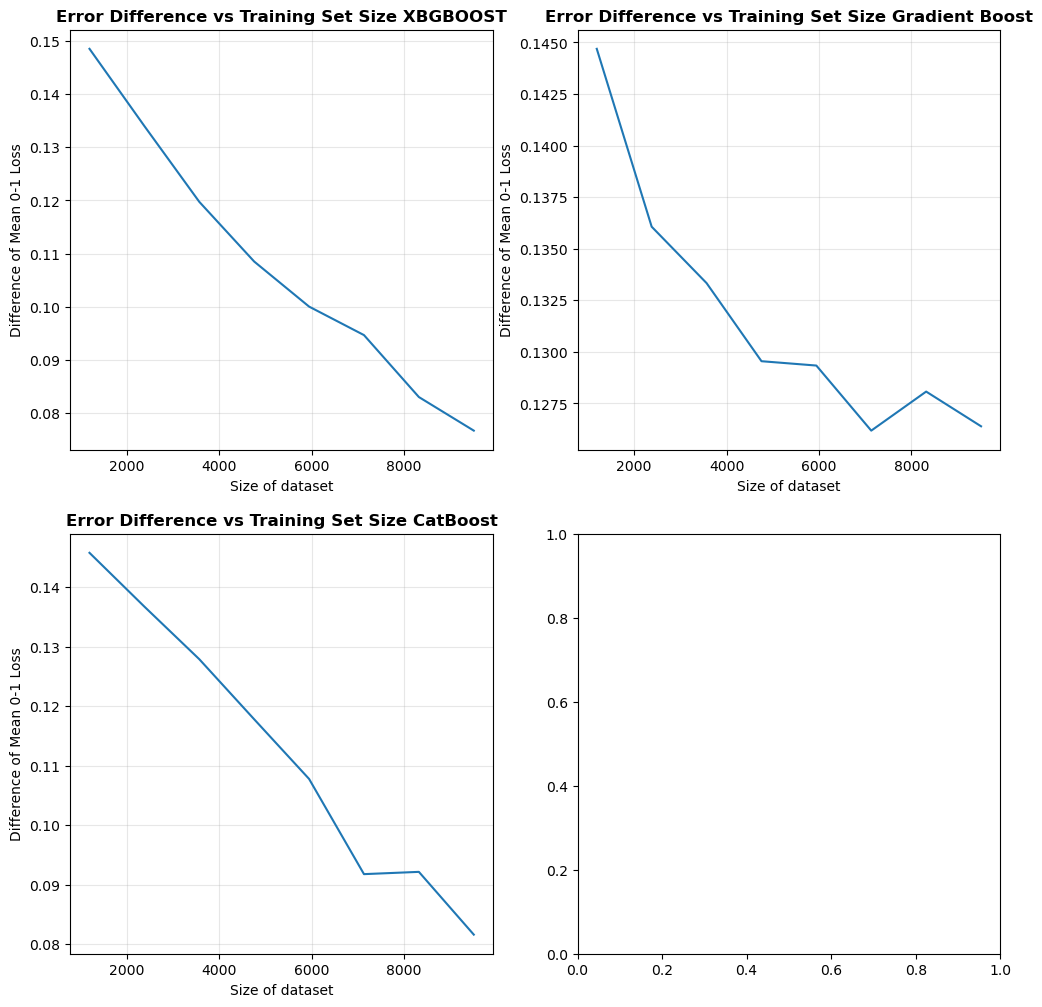

In [ ]:
ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)


xgb_bestfoundparams = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

cat_bestpar = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    'iterations': 1000,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 5,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0,
    'random_strength': 0    # Adding noise to splits to avoid overfitting
}

gb_bestparams = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

gb_bestparams = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 6,
    'subsample': 0.6,
    'max_features': 0.7, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

perc= np.linspace(0,1.0, 10)
size = np.ceil(perc*X_training.shape[0])
performance_xgb= []
performance_gb= []
performance_cb= []
for p in perc[1:-1]:
    X_train, _, Y_train, _ = train_test_split(
        X_training, Y_training, test_size=1.0-p, random_state=42, stratify=Y_training
    )

    final_model_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    final_model_xgb.fit(X_train, Y_train)
    final_model_gb = GradientBoostingClassifier(**gb_bestparams)
    final_model_gb.fit(X_train, Y_train)
    final_model_cb = cb.CatBoostClassifier(**cat_bestpar)
    final_model_cb.fit(X_train, Y_train)

    y_train_xgb = final_model_xgb.predict(X_train)
    y_pred_final_xgb = final_model_xgb.predict(X_test)

    y_train_gb = final_model_gb.predict(X_train)
    y_pred_final_gb = final_model_gb.predict(X_test)

    y_train_cb = final_model_cb.predict(X_train)
    y_pred_final_cb = final_model_cb.predict(X_test)
    y_prob_final_cb = final_model_cb.predict_proba(X_test)[:, 1]

    train_accuracy_xgb = accuracy_score(Y_train,y_train_xgb)
    acc_final_xgb = accuracy_score(Y_test, y_pred_final_xgb)
    performance_xgb.append(np.abs(train_accuracy_xgb-acc_final_xgb))

    train_accuracy_gb = accuracy_score(Y_train,y_train_gb)
    acc_final_gb = accuracy_score(Y_test, y_pred_final_gb)
    performance_gb.append(np.abs(train_accuracy_gb-acc_final_gb))

    train_accuracy_cb = accuracy_score(Y_train,y_train_cb)
    acc_final_cb = accuracy_score(Y_test, y_pred_final_cb)
    performance_cb.append(np.abs(train_accuracy_cb-acc_final_cb))
fig,ax= plt.subplots(nrows=2,ncols=2, figsize=(12,12))
ax1,ax2,ax3,ax4= ax.flatten()
ax1.plot(size[1:-1],performance_xgb, label="Error Difference")
ax1.set_title(f'Error Difference vs Training Set Size XBGBOOST', fontweight='bold')
ax1.set_xlabel('Size of dataset')
ax1.set_ylabel('Difference of Mean 0-1 Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(size[1:-1],performance_gb, label="Error Difference")
ax2.set_title(f'Error Difference vs Training Set Size Gradient Boost', fontweight='bold')
ax2.set_xlabel('Size of dataset')
ax2.set_ylabel('Difference of Mean 0-1 Loss')
ax2.grid(True, alpha=0.3)
ax3.plot(size[1:-1],performance_cb, label="Error Difference")
ax3.set_title(f'Error Difference vs Training Set Size CatBoost', fontweight='bold')
ax3.set_xlabel('Size of dataset')
ax3.set_ylabel('Difference of Mean 0-1 Loss')
ax3.grid(True, alpha=0.3)

## Performance with noise

In [ ]:
xgb_bestfoundparams = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

cat_bestpar = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    'iterations': 1000,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 5,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0,
    'random_strength': 0    # Adding noise to splits to avoid overfitting
}

gb_bestparams = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

gb_bestparams = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 6,
    'subsample': 0.6,
    'max_features': 0.7, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}
feature_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist'
]



X_training = pd.DataFrame(X_training, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)


# XGBoost Clean
clean_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
clean_xgb.fit(X_training, Y_training)
err_clean_xgb = 1 - accuracy_score(Y_test, clean_xgb.predict(X_test))

# GB Clean
clean_gb = GradientBoostingClassifier(**gb_bestparams)
clean_gb.fit(X_training, Y_training)
err_clean_gb = 1 - accuracy_score(Y_test, clean_gb.predict(X_test))

# CatBoost Clean
clean_cb = cb.CatBoostClassifier(**cat_bestpar)
clean_cb.fit(X_training, Y_training)
err_clean_cb = 1 - accuracy_score(Y_test, clean_cb.predict(X_test))


errors_noisy_xgb = []
errors_noisy_gb = []
errors_noisy_cb = []
plot_features = []

for col in X_training.columns:
    plot_features.append(col)

    # Dataset with noise added to one feature
    X_noisy = X_training.copy()
    std = X_noisy[col].std()
    if std == 0: std = 1.0

    # Adding noise to one row
    noise = np.random.normal(0, std * 0.05, size=X_noisy[col].shape)
    X_noisy[col] = X_noisy[col] + noise

    # XGBoost Noisy
    m_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    m_xgb.fit(X_noisy, Y_training)
    errors_noisy_xgb.append(1 - accuracy_score(Y_test, m_xgb.predict(X_test)))

    # GB Noisy
    m_gb = GradientBoostingClassifier(**gb_bestparams)
    m_gb.fit(X_noisy, Y_training)
    errors_noisy_gb.append(1 - accuracy_score(Y_test, m_gb.predict(X_test)))

    # CB Noisy
    m_cb = cb.CatBoostClassifier(**cat_bestpar)
    m_cb.fit(X_noisy, Y_training)
    errors_noisy_cb.append(1 - accuracy_score(Y_test, m_cb.predict(X_test)))

# Plotting
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 18), sharex=True)
x = np.arange(len(plot_features))
width = 0.35

# List of parameters for each plot
configs = [
    (axes[0], 'XGBoost', err_clean_xgb, errors_noisy_xgb, '#3498db'),
    (axes[1], 'Gradient Boosting', err_clean_gb, errors_noisy_gb, '#2ecc71'),
    (axes[2], 'CatBoost', err_clean_cb, errors_noisy_cb, '#e67e22')
]

for ax, name, clean_err, noisy_errs, color in configs:
    rects1 = ax.bar(x - width/2, [clean_err]*len(x), width, label='Errore Senza Rumore (Baseline)', color='lightgray', edgecolor='grey')

    # Colored bar: error with noise
    rects2 = ax.bar(x + width/2, noisy_errs, width, label='Errore Con Rumore (5%)', color=color, edgecolor='black')

    ax.set_title(f'{name}: Confronto Errore Clean vs Noisy', fontweight='bold', fontsize=12)
    ax.set_ylabel('Errore (1 - Accuracy)')
    ax.legend(loc='upper right')
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[2].set_xlabel('Feature corrotta dal rumore', fontweight='bold', fontsize=12)
axes[2].set_xticks(x)
axes[2].set_xticklabels(plot_features, rotation=45, ha='right')

plt.tight_layout()
plt.show()

NameError: name 'ratio' is not defined

# Data Augmentation

Calcolo errore originale (senza augmentation)...
Inizio analisi augmentation...


C:\Users\matte\anaconda3_2\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Completato livello rumore: 0.000


C:\Users\matte\anaconda3_2\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Completato livello rumore: 0.011


...

Completato livello rumore: 0.078


C:\Users\matte\anaconda3_2\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Completato livello rumore: 0.089


C:\Users\matte\anaconda3_2\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but GradientBoostingClassifier was fitted without feature names
  warnings.warn(


Completato livello rumore: 0.100


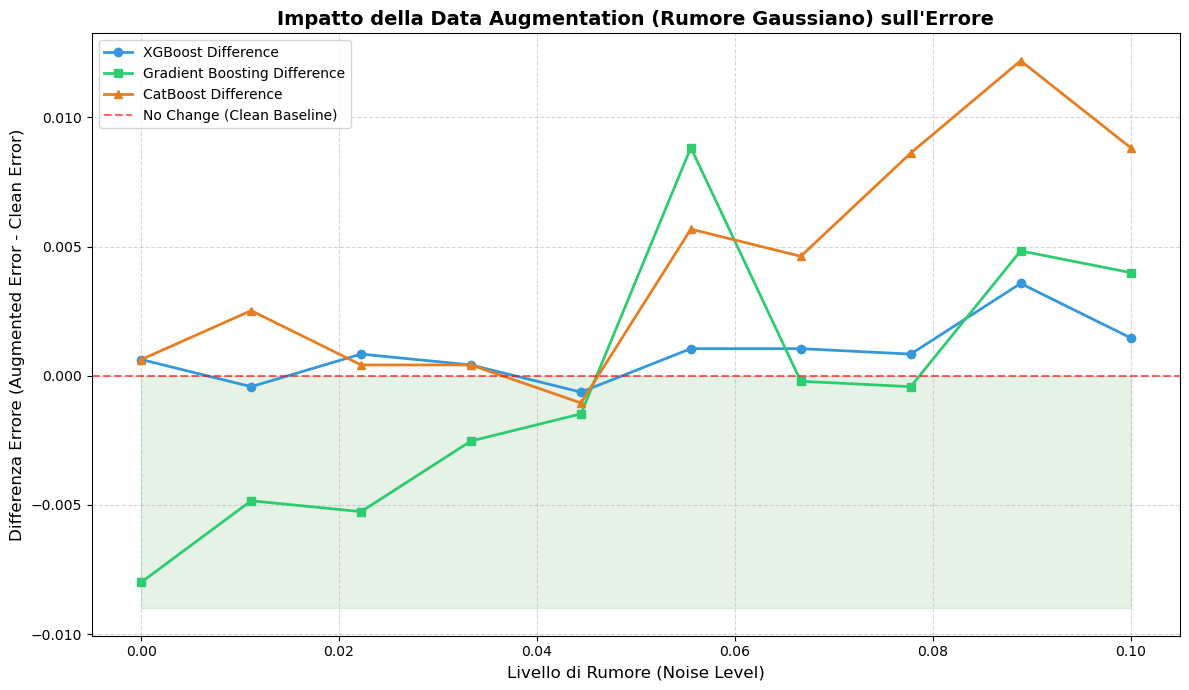

In [ ]:
def rigorous_augmentation(X, y, noise_level=0.01, multiplier=2):
    X_augmented_list = [X]
    y_augmented_list = [y]

    stds = np.std(X, axis=0)

    for _ in range(multiplier - 1):
        # Generates gaussian noise
        noise = np.random.normal(0, stds * noise_level, size=X.shape)
        X_noisy = X + noise
        X_augmented_list.append(X_noisy)
        y_augmented_list.append(y)

    return np.vstack(X_augmented_list), np.concatenate(y_augmented_list)

xgb_bestfoundparams = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

cat_bestpar = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    'iterations': 1000,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 5,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0,
    'random_strength': 0    # Adding noise to splits to avoid overfitting
}

gb_bestparams = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

gb_bestparams = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 6,
    'subsample': 0.6,
    'max_features': 0.7, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}


# XGBoost Clean
clean_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
clean_xgb.fit(X_training, Y_training)
err_clean_xgb = 1 - accuracy_score(Y_test, clean_xgb.predict(X_test))

# GB Clean
clean_gb = GradientBoostingClassifier(**gb_bestparams)
clean_gb.fit(X_training, Y_training)
err_clean_gb = 1 - accuracy_score(Y_test, clean_gb.predict(X_test))

# CatBoost Clean
clean_cb = cb.CatBoostClassifier(**cat_bestpar)
clean_cb.fit(X_training, Y_training)
err_clean_cb = 1 - accuracy_score(Y_test, clean_cb.predict(X_test))

noise_levels = np.linspace(0, 0.1, 10)
diff_xgb = []
diff_gb = []
diff_cb = []


for p in noise_levels:
    # Generate augmented data
    X_aug, y_aug = rigorous_augmentation(X_training, Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    m_xgb.fit(X_aug, y_aug)
    err_aug_xgb = 1 - accuracy_score(Y_test, m_xgb.predict(X_test))
    diff_xgb.append(err_aug_xgb - err_clean_xgb)

    # GB
    m_gb = GradientBoostingClassifier(**gb_bestparams)
    m_gb.fit(X_aug, y_aug)
    err_aug_gb = 1 - accuracy_score(Y_test, m_gb.predict(X_test))
    diff_gb.append(err_aug_gb - err_clean_gb)

    # CB
    m_cb = cb.CatBoostClassifier(**cat_bestpar)
    m_cb.fit(X_aug, y_aug)
    err_aug_cb = 1 - accuracy_score(Y_test, m_cb.predict(X_test))
    diff_cb.append(err_aug_cb - err_clean_cb)

    print(f"Completato livello rumore: {p:.3f}")


plt.figure(figsize=(12, 7))

plt.plot(noise_levels, diff_xgb, marker='o', label='XGBoost Difference', color='blue', linewidth=2)
plt.plot(noise_levels, diff_gb, marker='s', label='Gradient Boosting Difference', color='orange', linewidth=2)
plt.plot(noise_levels, diff_cb, marker='^', label='CatBoost Difference', color='green', linewidth=2)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No Change (Clean Baseline)')

plt.title('Impatto della Data Augmentation (Rumore Gaussiano) sull\'Errore', fontweight='bold', fontsize=14)
plt.xlabel('Livello di Rumore (Noise Level)', fontsize=12)
plt.ylabel('Differenza Errore (Augmented Error - Clean Error)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.fill_between(noise_levels, 0, plt.ylim()[0], color='green', alpha=0.1, label='Improvement Zone')

plt.tight_layout()
plt.show()

# Results with Principal Component Analysis


---> Inizio ottimizzazione per 6 Componenti PCA...
Done d=6 -> AUC: 0.8884, Loss: 0.1907

---> Inizio ottimizzazione per 7 Componenti PCA...
Done d=7 -> AUC: 0.8978, Loss: 0.1775

---> Inizio ottimizzazione per 8 Componenti PCA...
Done d=8 -> AUC: 0.9055, Loss: 0.1716

---> Inizio ottimizzazione per 9 Componenti PCA...
Done d=9 -> AUC: 0.9258, Loss: 0.1369

---> Inizio ottimizzazione per 10 Componenti PCA...
Done d=10 -> AUC: 0.9302, Loss: 0.1348


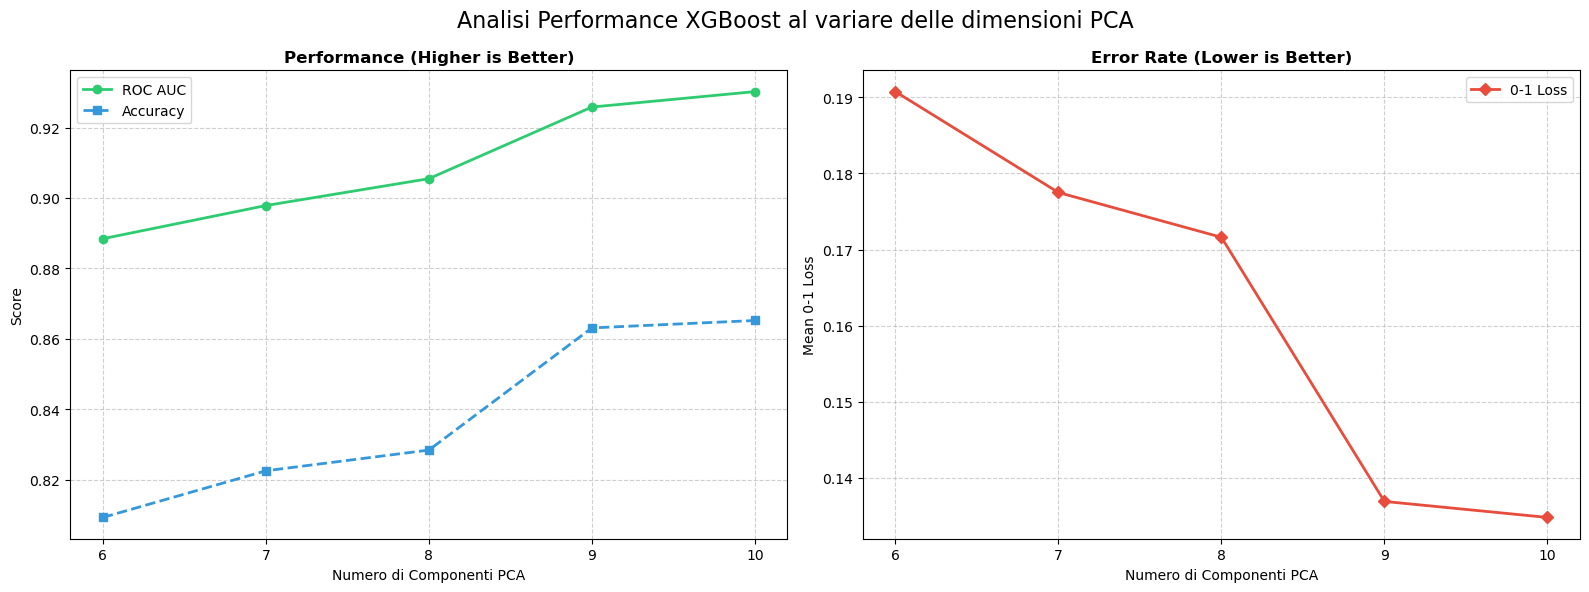

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

dims_list = []
auc_scores = []
accuracy_scores = []
loss_scores = []

# Cycle on dimensions
for d in range(6, 11):

    # Scaler and PCA
    scaler = StandardScaler()
    pca = PCA(n_components=d)

    X_train_scaled = scaler.fit_transform(X_training)
    X_test_scaled = scaler.transform(X_test)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    # Find best parameters with optuna
    def objective(trial):
        param_space = {
            'booster': 'gbtree',
            'objective': 'binary:logistic',
            'n_jobs': -1,
            'scale_pos_weight': ratio,
            'tree_method': 'hist',
            'verbosity': 0,

            # Range of parameters
            'gamma': trial.suggest_float('gamma', 0, 5),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 100, log=True),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
        }

        xgb_model = xgb.XGBClassifier(**param_space, random_state=42)

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(xgb_model, X_train_pca, Y_training, cv=cv, scoring='roc_auc').mean()

        return score

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    final_params = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'random_state': 42,
        **study.best_params # Unpacking parameters
    }

    best_model_optuna = xgb.XGBClassifier(**final_params)
    best_model_optuna.fit(X_train_pca, Y_training)

    # Evaluation
    y_pred_opt = best_model_optuna.predict(X_test_pca)
    y_prob_opt = best_model_optuna.predict_proba(X_test_pca)[:, 1]

    auc_opt = roc_auc_score(Y_test, y_prob_opt)
    acc_opt = accuracy_score(Y_test, y_pred_opt)
    loss_01 = 1 - acc_opt

    # save results
    dims_list.append(d)
    auc_scores.append(auc_opt)
    accuracy_scores.append(acc_opt)
    loss_scores.append(loss_01)

    print(f"Done d={d} -> AUC: {auc_opt:.4f}, Loss: {loss_01:.4f}")

# PLot

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ax1.plot(dims_list, auc_scores, marker='o', linestyle='-', linewidth=2, color='green', label='ROC AUC')
ax1.plot(dims_list, accuracy_scores, marker='s', linestyle='--', linewidth=2, color='blue', label='Accuracy')
ax1.set_title('Performance', fontweight='bold')
ax1.set_xlabel('Numero di Componenti PCA')
ax1.set_ylabel('Score')
ax1.set_xticks(dims_list)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()


plt.suptitle("Analisi Performance XGBoost al variare delle dimensioni PCA", fontsize=16)
plt.tight_layout()
plt.show()

## STARTING OF NEW PART AFTER PREVIOUS SEMESTER PROJECT

In [ ]:
import pandas as pd


def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",")
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.drop(columns=['Label']).values
    Y = data_train["Label"].values # Get the labels
    Y = Y.astype(int)
    return X,Y

X , Y = load_dataset("all_data.csv")
X_training, X_test, Y_training, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)



# CatBoost optuna

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'verbose': False,
        'random_seed': 42,

        # Parameters to optimize
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        'bootstrap_type': 'Bayesian',
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),

        'scale_pos_weight': float(ratio)
    }

    # model setup
    model = cb.CatBoostClassifier(**param_space)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # K fold score
    score = cross_val_score(model, X_training, Y_training, cv=cv, scoring='roc_auc').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("\nMigliori parametri CatBoost:")
print(study.best_params)
cat_bestoptuna= study.best_params

# Training on whole set
final_model_cb = cb.CatBoostClassifier(**study.best_params, verbose=False, random_seed=42, scale_pos_weight=ratio)
final_model_cb.fit(X_training, Y_training)

# Test set evaluation
y_pred = final_model_cb.predict(X_test)
y_prob = final_model_cb.predict_proba(X_test)[:, 1]

print(f"PERFORMANCE FINALE CATBOOST (TEST SET)")
print(f"ROC AUC:  {roc_auc_score(Y_test, y_prob):.4f}")
print(f"Accuracy: {accuracy_score(Y_test, y_pred):.4f}")
print(f"0-1 Loss: {1 - accuracy_score(Y_test, y_pred):.4f}")


Migliori parametri CatBoost:
{'iterations': 993, 'learning_rate': 0.07699471770335262, 'depth': 4, 'l2_leaf_reg': 5.593630924150531, 'random_strength': 1.6986674411200247, 'bagging_temperature': 0.3938541756073848}
PERFORMANCE FINALE CATBOOST (TEST SET)
ROC AUC:  0.9406
Accuracy: 0.8818
0-1 Loss: 0.1182


# XGBoost OPTUNA

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'n_jobs': -1,
        'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'verbosity': 0,

        # Define grid search
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 100, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000)
    }


    xgb_model = xgb.XGBClassifier(**param_space, random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(xgb_model, X_training, Y_training, cv=cv, scoring='roc_auc').mean()

    return score

# Study execution
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# Final results
print("\nParametri migliori trovati da Optuna:")
print(study.best_params)

# best found parameters
final_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'random_state': 42,
    **study.best_params
}

best_model_optuna = xgb.XGBClassifier(**final_params)
best_model_optuna.fit(X_training, Y_training)
xgb_bestoptuna= study.best_params
# Test set evaluation
y_pred_opt = best_model_optuna.predict(X_test)
y_prob_opt = best_model_optuna.predict_proba(X_test)[:, 1]

auc_opt = roc_auc_score(Y_test, y_prob_opt)
acc_opt = accuracy_score(Y_test, y_pred_opt)
loss_01 = 1 - acc_opt

print(f"ROC AUC Score: {auc_opt:.4f}")
print(f"Accuracy Score: {acc_opt:.4f}")
print(f"0-1 Mean Loss: {loss_01:.4f}")

# Adaptation to transformation of data

Performance of boosted bodels on randomly rotated dataset

TO DO: add neural network performance, we can discuss weather to add lightGBM

In [ ]:
# Create a Random Rotation Matrix (Orthogonal)
dim = X.shape[1]

perf_rot_xgboost = []
perf_rot_catboost = []
perf_rot_nn = []

for i in range(100):
    # Rotate the features
    rotation_matrix = ortho_group.rvs(dim)
    X_rotated = np.dot(X_training, rotation_matrix)
    X_test_rot = np.dot(X_test , rotation_matrix)

    rot_catboost = cb.CatBoostClassifier(**cat_bestoptuna)
    rot_catboost.fit(X_rotated, Y_training)
    y_prob_opt = rot_catboost.predict_proba(X_test)[:, 1]
    perf_rot_catboost.append(accuracy_score(Y_test,y_pred_opt))

    rot_xgb = xgb.XGBClassifier(**xgb_bestoptuna)
    rot_xgb.fit(X_rotated, Y_training)
    y_prob_opt = rot_xgb.predict_proba(X_test)[:, 1]
    perf_rot_xgboost.append(accuracy_score(Y_test,y_pred_opt))


results = pd.DataFrame({
    'XGBoost': perf_rot_xgboost,
    'CatBoost': perf_rot_catboost,
    'NN': perf_rot_nn
})

summary = pd.DataFrame({
    'Mean': results.mean(),
    'Variance': results.var(),
    'Std Dev': results.std()
})

print("--- Rotation Robustness Summary ---")
print(summary)

# 3. PLOT THE CONFRONTATION
plt.figure(figsize=(10, 6))
sns.boxplot(data=results, palette="viridis")
sns.stripplot(data=results, color="black", alpha=0.3, jitter=True) # Adds individual dots
plt.title('Model Stability Under 100 Random Rotations', fontsize=15)
plt.ylabel('Accuracy Score')
plt.xlabel('Model Type')
plt.grid(axis='y', alpha=0.3)
plt.show()


NameError: name 'ortho_group' is not defined

# Performance on images

In [ ]:
! pip install torch


   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/114.6 MB 9.9 MB/s eta 0:00:12
   - -------------------------------------- 3.7/114.6 MB 11.9 MB/s eta 0:00:10
   -- ------------------------------------- 5.8/114.6 MB 10.8 MB/s eta 0:00:11
   --- ------------------------------------ 8.9/114.6 MB 11.9 MB/s eta 0:00:09
   ---- ----------------------------------- 12.1/114.6 MB 12.5 MB/s eta 0:00:09
   ----- ---------------------------------- 14.9/114.6 MB 12.8 MB/s eta 0:00:08
   ------ --------------------------------- 18.1/114.6 MB 13.1 MB/s eta 0:00:08
   ------- -------------------------------- 21.2/114.6 MB 13.3 MB/s eta 0:00:08
   -------- ------------------------------- 24.1/114.6 MB 13.4 MB/s eta 0:00:07
   --------- ------------------------------ 27.3/114.6 MB 13.5 MB/s eta 0:00:07
   ---------- ----------------------------- 30.4/114.6 MB 13.5 MB/s eta 0:00:07
   ----------- ---------------------------- 33.6/114.6

In [ ]:
! pip install torchvision

   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ------------------------ --------------- 2.6/4.3 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 4.3/4.3 MB 11.9 MB/s  0:00:00


Performance of xgboost on single MNIST dataset

In [ ]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

dataset = MNIST(root="./", train=False, download=True)
x_train = dataset.data.numpy()
y_train = dataset.targets.numpy()

# Salvataggio in due file separati
np.save('mnist_x_test.npy', x_train)
np.save('mnist_y_test.npy', y_train)
print(x_test.shape)
print("File salvati correttamente!")

X_flat = x_train.reshape(10000, 784)
clean_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
clean_xgb.fit(X_flat, y_train)
err_clean_xgb = 1 - accuracy_score(Y_test, clean_xgb.predict(X_test))
print(err_clean_xgb)

(10000, 28, 28)
File salvati correttamente!


NameError: name 'xgb_bestfoundparams' is not defined

# Performance with different dimensions of the dataset

Performance with increasing number of input points

TO DO: add performance with NN

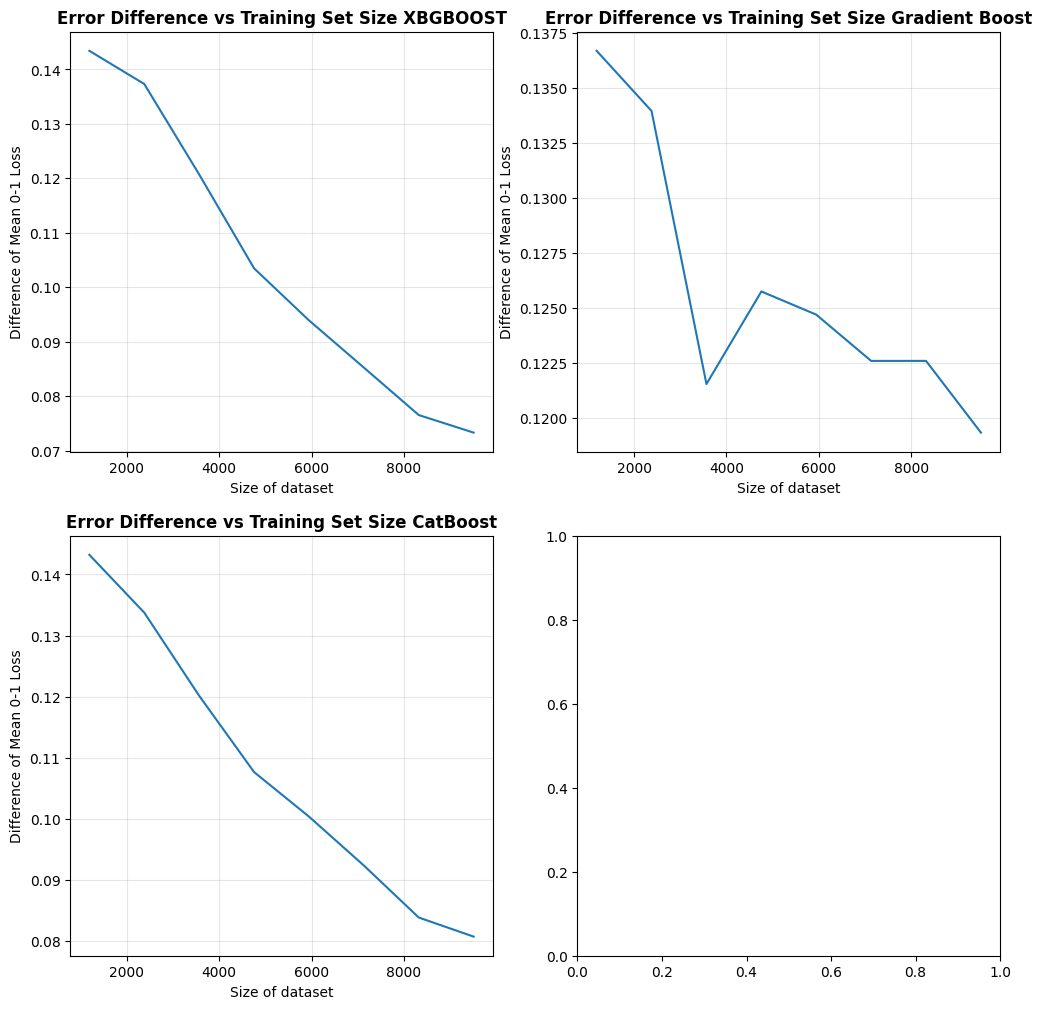

In [ ]:
ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)


xgb_bestfoundparams = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'error',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

cat_bestpar = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    'iterations': 1000,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 5,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0,
    'random_strength': 0    # Adding noise to splits to avoid overfitting
}

gb_bestparams = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

gb_bestparams = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 6,
    'subsample': 0.6,
    'max_features': 0.7, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

perc= np.linspace(0,1.0, 10)
size = np.ceil(perc*X_training.shape[0])
performance_xgb= []
performance_gb= []
performance_cb= []
for p in perc[1:-1]:
    X_train, _, Y_train, _ = train_test_split(
        X_training, Y_training, test_size=1.0-p, random_state=42, stratify=Y_training
    )

    final_model_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    final_model_xgb.fit(X_train, Y_train)
    final_model_gb = GradientBoostingClassifier(**gb_bestparams)
    final_model_gb.fit(X_train, Y_train)
    final_model_cb = cb.CatBoostClassifier(**cat_bestpar)
    final_model_cb.fit(X_train, Y_train)

    y_train_xgb = final_model_xgb.predict(X_train)
    y_pred_final_xgb = final_model_xgb.predict(X_test)

    y_train_gb = final_model_gb.predict(X_train)
    y_pred_final_gb = final_model_gb.predict(X_test)

    y_train_cb = final_model_cb.predict(X_train)
    y_pred_final_cb = final_model_cb.predict(X_test)
    y_prob_final_cb = final_model_cb.predict_proba(X_test)[:, 1]

    train_accuracy_xgb = accuracy_score(Y_train,y_train_xgb)
    acc_final_xgb = accuracy_score(Y_test, y_pred_final_xgb)
    performance_xgb.append(np.abs(train_accuracy_xgb-acc_final_xgb))

    train_accuracy_gb = accuracy_score(Y_train,y_train_gb)
    acc_final_gb = accuracy_score(Y_test, y_pred_final_gb)
    performance_gb.append(np.abs(train_accuracy_gb-acc_final_gb))

    train_accuracy_cb = accuracy_score(Y_train,y_train_cb)
    acc_final_cb = accuracy_score(Y_test, y_pred_final_cb)
    performance_cb.append(np.abs(train_accuracy_cb-acc_final_cb))
fig,ax= plt.subplots(nrows=2,ncols=2, figsize=(12,12))
ax1,ax2,ax3,ax4= ax.flatten()
ax1.plot(size[1:-1],performance_xgb, label="Error Difference")
ax1.set_title(f'Error Difference vs Training Set Size XBGBOOST', fontweight='bold')
ax1.set_xlabel('Size of dataset')
ax1.set_ylabel('Difference of Mean 0-1 Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(size[1:-1],performance_gb, label="Error Difference")
ax2.set_title(f'Error Difference vs Training Set Size Gradient Boost', fontweight='bold')
ax2.set_xlabel('Size of dataset')
ax2.set_ylabel('Difference of Mean 0-1 Loss')
ax2.grid(True, alpha=0.3)
ax3.plot(size[1:-1],performance_cb, label="Error Difference")
ax3.set_title(f'Error Difference vs Training Set Size CatBoost', fontweight='bold')
ax3.set_xlabel('Size of dataset')
ax3.set_ylabel('Difference of Mean 0-1 Loss')
ax3.grid(True, alpha=0.3)

NOISE PERFORMANCE


Performance of the models with increasing noise on the dataset

TO DO: add performance with NN

Completato livello rumore: 0.000
Completato livello rumore: 0.011
Completato livello rumore: 0.022
Completato livello rumore: 0.033
Completato livello rumore: 0.044
Completato livello rumore: 0.056
Completato livello rumore: 0.067
Completato livello rumore: 0.078
Completato livello rumore: 0.089
Completato livello rumore: 0.100


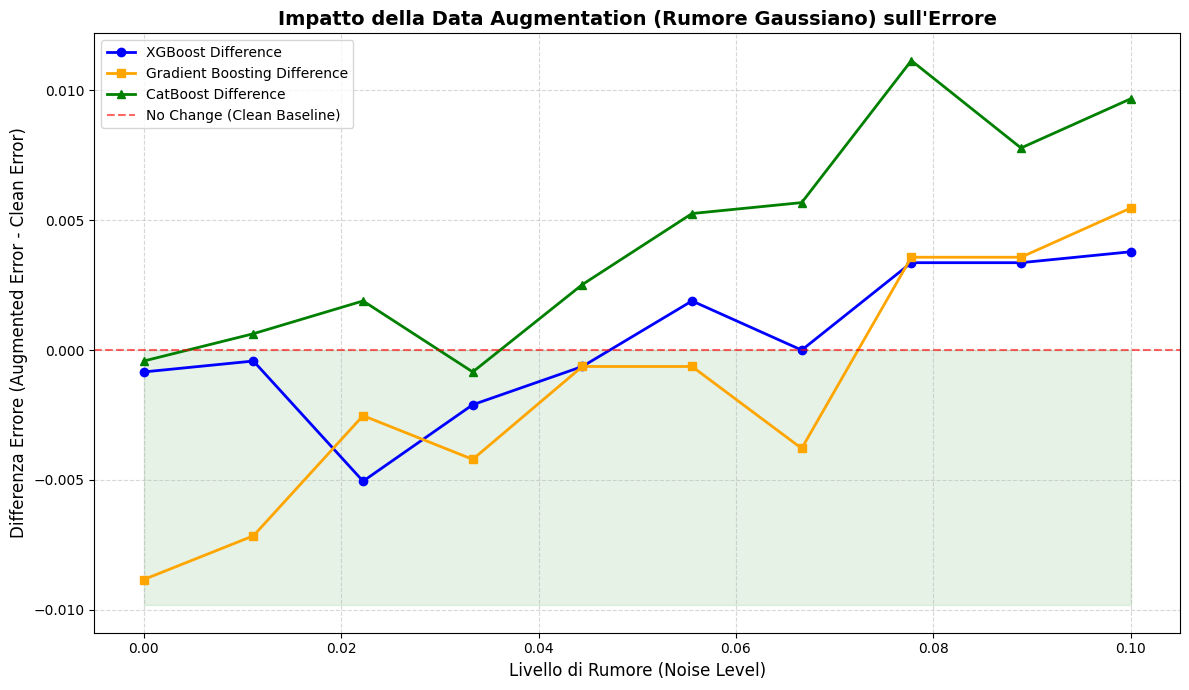

In [ ]:
def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",", names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
    ])
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.iloc[:, 0:10].values # Get first two columns as the input
    Y = data_train.iloc[:, 10].values # Get the third column as the label
    Y[Y=="g"]=1
    Y[Y=="h"]=0
    Y = Y.astype(int)
    return X,Y



# Load the dataset
X, Y = load_dataset("https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data")


# Division between test and train dataset
rng = rnd.Random(42)
idx = list(range(X.shape[0]))
test_idx = rng.sample(idx, int(X.shape[0]*0.25))
train_idx = [i for i in idx if i not in test_idx]
X_training = X[train_idx]
X_test  = X[test_idx]
Y_training = Y[train_idx]
Y_test  = Y[test_idx]

# Validation set definition
idx = list(range(X_training.shape[0]))
val_idx = rng.sample(idx, int(X_training.shape[0]*0.25))
train_idx = [i for i in idx if i not in val_idx]
X_val  = X_training[val_idx]
X_training = X_training[train_idx]
Y_val  = Y_training[val_idx]
Y_training = Y_training[train_idx]

ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1)





def rigorous_augmentation(X, y, noise_level=0.01, multiplier=2):
    X_augmented_list = [X]
    y_augmented_list = [y]

    stds = np.std(X, axis=0)

    for _ in range(multiplier - 1):
        # Generates gaussian noise
        noise = np.random.normal(0, stds * noise_level, size=X.shape)
        X_noisy = X + noise
        X_augmented_list.append(X_noisy)
        y_augmented_list.append(y)

    return np.vstack(X_augmented_list), np.concatenate(y_augmented_list)

xgb_bestfoundparams = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'auc',  # changed from the auc score to 0-1 loss metric
    'verbosity': 0,
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

cat_bestpar = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'task_type': 'CPU',
    'verbose': False,
    'random_seed': 42,
    'iterations': 1000,      # equivalent to number of estimators
    'learning_rate': 0.05,
    'depth': 6,             # equivalent to max_depth
    'l2_leaf_reg': 5,       # L2 regulation
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0,
    'random_strength': 0    # Adding noise to splits to avoid overfitting
}

gb_bestparams = {
    'n_estimators': 100,
    'learning_rate': 0.1,
    'max_depth': 3,
    'subsample': 1.0,
    'max_features': None, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}

gb_bestparams = {
    'n_estimators': 500,
    'learning_rate': 0.2,
    'max_depth': 6,
    'subsample': 0.6,
    'max_features': 0.7, # Equivalente a colsample_bytree=1.0
    'random_state': 42
}


# XGBoost Clean
clean_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
clean_xgb.fit(X_training, Y_training)
err_clean_xgb = 1 - accuracy_score(Y_test, clean_xgb.predict(X_test))

# GB Clean
clean_gb = GradientBoostingClassifier(**gb_bestparams)
clean_gb.fit(X_training, Y_training)
err_clean_gb = 1 - accuracy_score(Y_test, clean_gb.predict(X_test))

# CatBoost Clean
clean_cb = cb.CatBoostClassifier(**cat_bestpar)
clean_cb.fit(X_training, Y_training)
err_clean_cb = 1 - accuracy_score(Y_test, clean_cb.predict(X_test))

noise_levels = np.linspace(0, 0.1, 10)
diff_xgb = []
diff_gb = []
diff_cb = []


for p in noise_levels:
    # Generate augmented data
    X_aug, y_aug = rigorous_augmentation(X_training, Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    m_xgb.fit(X_aug, y_aug)
    err_aug_xgb = 1 - accuracy_score(Y_test, m_xgb.predict(X_test))
    diff_xgb.append(err_aug_xgb - err_clean_xgb)

    # GB
    m_gb = GradientBoostingClassifier(**gb_bestparams)
    m_gb.fit(X_aug, y_aug)
    err_aug_gb = 1 - accuracy_score(Y_test, m_gb.predict(X_test))
    diff_gb.append(err_aug_gb - err_clean_gb)

    # CB
    m_cb = cb.CatBoostClassifier(**cat_bestpar)
    m_cb.fit(X_aug, y_aug)
    err_aug_cb = 1 - accuracy_score(Y_test, m_cb.predict(X_test))
    diff_cb.append(err_aug_cb - err_clean_cb)

    print(f"Completato livello rumore: {p:.3f}")


plt.figure(figsize=(12, 7))

plt.plot(noise_levels, diff_xgb, marker='o', label='XGBoost Difference', color='blue', linewidth=2)
plt.plot(noise_levels, diff_gb, marker='s', label='Gradient Boosting Difference', color='orange', linewidth=2)
plt.plot(noise_levels, diff_cb, marker='^', label='CatBoost Difference', color='green', linewidth=2)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No Change (Clean Baseline)')

plt.title('Impatto della Data Augmentation (Rumore Gaussiano) sull\'Errore', fontweight='bold', fontsize=14)
plt.xlabel('Livello di Rumore (Noise Level)', fontsize=12)
plt.ylabel('Differenza Errore (Augmented Error - Clean Error)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.fill_between(noise_levels, 0, plt.ylim()[0], color='green', alpha=0.1, label='Improvement Zone')

plt.tight_layout()
plt.show()

Noise performance with relabeling

TO DO: add performance with NN

In [ ]:
def inject_label_noise(y, noise_level=0.1):

    # Create a copy to avoid modifying the original training data
    y_noisy = np.array(y).copy()
    n_samples = len(y_noisy)

    # Calculate the number of labels to be flipped
    n_to_flip = int(noise_level * n_samples)

    # Randomly select indices to corrupt without replacement
    indices_to_flip = np.random.choice(n_samples, n_to_flip, replace=False)

    # Identify unique classes in the dataset to know the possible alternatives
    unique_classes = np.unique(y_noisy)

    for idx in indices_to_flip:
        original_label = y_noisy[idx]

        # Ensure the new label is ALWAYS different from the original one
        possible_labels = [c for c in unique_classes if c != original_label]
        y_noisy[idx] = np.random.choice(possible_labels)[0]

    return y_noisy


noise_levels = np.linspace(0, 0.2, 10)
diff_xgb = []
diff_gb = []
diff_cb = []


for p in noise_levels:
    # Generate augmented data
    X_aug= X_training.copy()
    Y_aug = inject_label_noise(Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
    m_xgb.fit(X_aug, y_aug)
    err_aug_xgb = 1 - accuracy_score(Y_test.ravel(), m_xgb.predict(X_test).ravel())
    diff_xgb.append(err_aug_xgb - err_clean_xgb)

    # GB
    m_gb = GradientBoostingClassifier(**gb_bestparams)
    m_gb.fit(X_aug, y_aug)
    err_aug_gb = 1 - accuracy_score(Y_test.ravel(), m_gb.predict(X_test).ravel())
    diff_gb.append(err_aug_gb - err_clean_gb)

    # CB
    m_cb = cb.CatBoostClassifier(**cat_bestpar)
    m_cb.fit(X_aug, y_aug)
    err_aug_cb = 1 - accuracy_score(Y_test.ravel(), m_cb.predict(X_test).ravel())
    diff_cb.append(err_aug_cb - err_clean_cb)

    print(f"Completato livello rumore: {p:.3f}")


plt.figure(figsize=(12, 7))

plt.plot(noise_levels, diff_xgb, marker='o', label='XGBoost Difference', color='blue', linewidth=2)
plt.plot(noise_levels, diff_gb, marker='s', label='Gradient Boosting Difference', color='orange', linewidth=2)
plt.plot(noise_levels, diff_cb, marker='^', label='CatBoost Difference', color='green', linewidth=2)

plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No Change (Clean Baseline)')

plt.title('Impatto della Data Augmentation (Rumore Gaussiano) sull\'Errore', fontweight='bold', fontsize=14)
plt.xlabel('Livello di Rumore (Noise Level)', fontsize=12)
plt.ylabel('Differenza Errore (Augmented Error - Clean Error)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.fill_between(noise_levels, 0, plt.ylim()[0], color='green', alpha=0.1, label='Improvement Zone')

plt.tight_layout()
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [4755, 9510]

ADAPTABILITY OF MODELS TO APPLICATION OF NOISE TO MOST IMPORTANT FEATURES

Identifying the most important features in the dataset

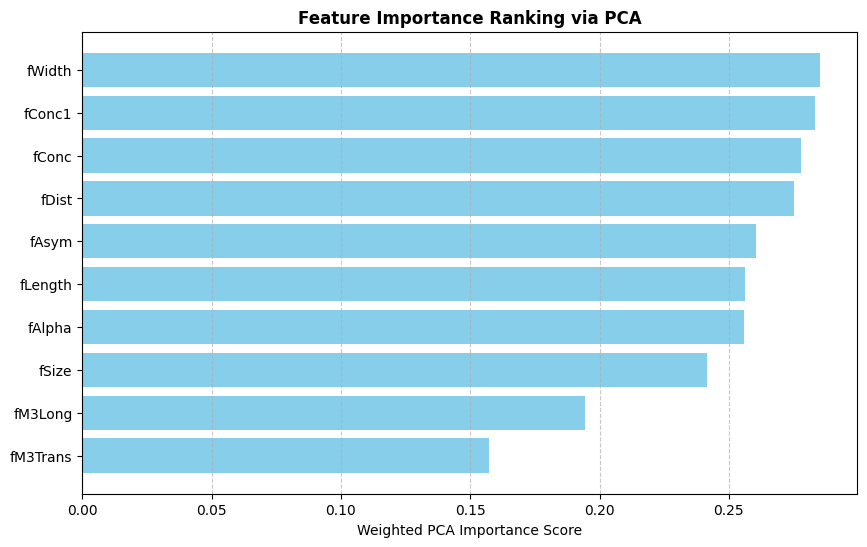

    Feature  Importance
1    fWidth    0.285340
4    fConc1    0.283206
3     fConc    0.277707
9     fDist    0.275275
5     fAsym    0.260473
0   fLength    0.256370
8    fAlpha    0.255748
2     fSize    0.241665
6   fM3Long    0.194270
7  fM3Trans    0.157366


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_training)

# 2. Fit PCA
pca = PCA()
pca.fit(X_scaled)

# 3. Extract Loadings (components_) and Explained Variance Ratio
# components_ shape: (n_components, n_features)
loadings = pca.components_
exp_var_ratio = pca.explained_variance_ratio_

# 4. Calculate Weighted Feature Importance
# We take the absolute value of loadings and multiply by the variance of each PC
weighted_loadings = np.abs(loadings.T) * exp_var_ratio
feature_importance = np.sum(weighted_loadings, axis=1)

feature_names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist'
]

ranking_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
})

# 6. Sort the classification
ranking_df = ranking_df.sort_values(by='Importance', ascending=False)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.barh(ranking_df['Feature'], ranking_df['Importance'], color='skyblue')
plt.xlabel('Weighted PCA Importance Score')
plt.title('Feature Importance Ranking via PCA', fontweight='bold')
plt.gca().invert_yaxis() # Highest importance on top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(ranking_df)

TO DO: add neural network part and we can discuss to substitute plain gradient boost with light gbm

NameError: name 'cat_bestparil' is not defined

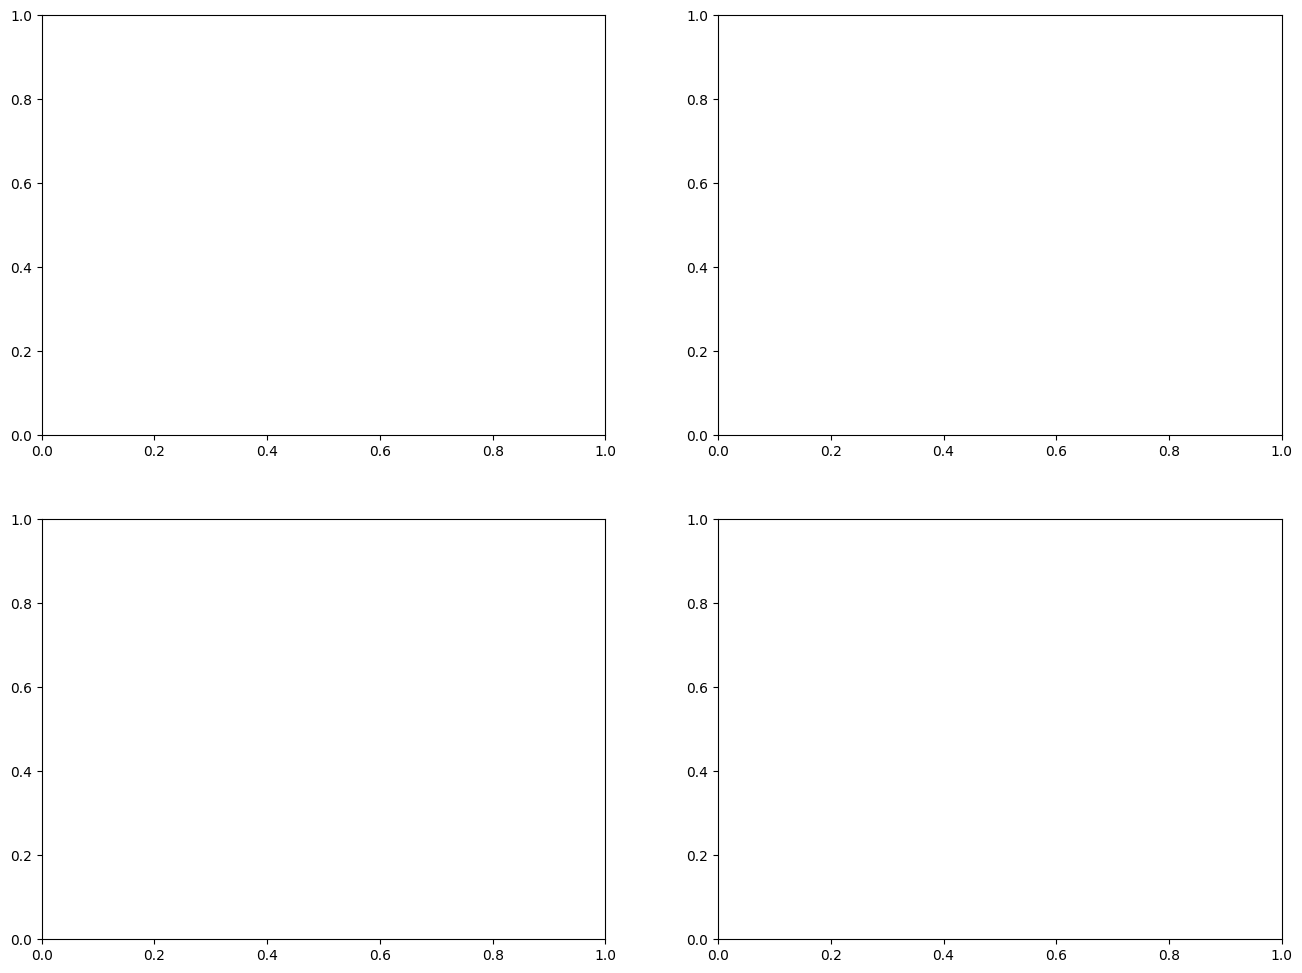

In [ ]:
noise_levels = np.linspace(0, 0.1, 10)
max_features_to_corrupt = 4
fig, axes = plt.subplots(2, 2, figsize=(16, 12)) # 4 subplots (1 for each feature count)
axes = axes.flatten()


for n_feat in range(1, max_features_to_corrupt + 1):
    diff_xgb, diff_gb, diff_cb = [], [], []

    # Identify which columns to corrupt (0, then 0-1, then 0-2, etc.)
    target_cols = list(range(n_feat))

    for p in noise_levels:
        # 1. Generate selectively noisy data
        X_aug = X_training.copy()
        y_aug = Y_training.copy()

        # Apply Gaussian noise ONLY to the selected features
        for col_idx in target_cols:
            # We assume X_training is a numpy array or we use .iloc for pandas
            std_dev = X_aug[:, col_idx].std() if isinstance(X_aug, np.ndarray) else X_aug.iloc[:, col_idx].std()
            noise = np.random.normal(0, p * std_dev, size=X_aug.shape[0])

            if isinstance(X_aug, np.ndarray):
                X_aug[:, col_idx] += noise
            else:
                X_aug.iloc[:, col_idx] += noise

        # 2. Train and Evaluate XGBoost
        m_xgb = xgb.XGBClassifier(**xgb_bestfoundparams)
        m_xgb.fit(X_aug, y_aug)
        err_aug_xgb = 1 - accuracy_score(Y_test, m_xgb.predict(X_test))
        diff_xgb.append(err_aug_xgb - err_clean_xgb)

        # 3. Train and Evaluate Gradient Boosting
        m_gb = GradientBoostingClassifier(**gb_bestparams)
        m_gb.fit(X_aug, y_aug)
        err_aug_gb = 1 - accuracy_score(Y_test, m_gb.predict(X_test))
        diff_gb.append(err_aug_gb - err_clean_gb)

        # 4. Train and Evaluate CatBoost
        m_cb = cb.CatBoostClassifier(**cat_bestparil)
        m_cb.fit(X_aug, y_aug)
        err_aug_cb = 1 - accuracy_score(Y_test, m_cb.predict(X_test))
        diff_cb.append(err_aug_cb - err_clean_cb)

    # --- Plotting for this specific number of features ---
    ax = axes[n_feat-1]
    ax.plot(noise_levels, diff_xgb, marker='o', label='XGBoost', color='blue')
    ax.plot(noise_levels, diff_gb, marker='s', label='GradBoost', color='orange')
    ax.plot(noise_levels, diff_cb, marker='^', label='CatBoost', color='green')

    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'Noise on first {n_feat} feature(s)', fontweight='bold')
    ax.set_xlabel('Noise Intensity')
    ax.set_ylabel('Error Difference')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle('Incremental Feature Corruption Stress Test', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# IMAGES ANALYSIS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Import the three boosting giants
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.ndimage import rotate

Analysis of performance of boosted models, only on vectorized images vs classification score obtained by first extracting vectors of features and then classify those

TO DO: just to review and clean ai comments

Loading MNIST data...
Extracting CNN features using MobileNetV2...
[Raw Pixels] Training XGBoost...
[Raw Pixels] Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Raw Pixels] Training CatBoost...
[CNN Features] Training XGBoost...
[CNN Features] Training LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CNN Features] Training CatBoost...


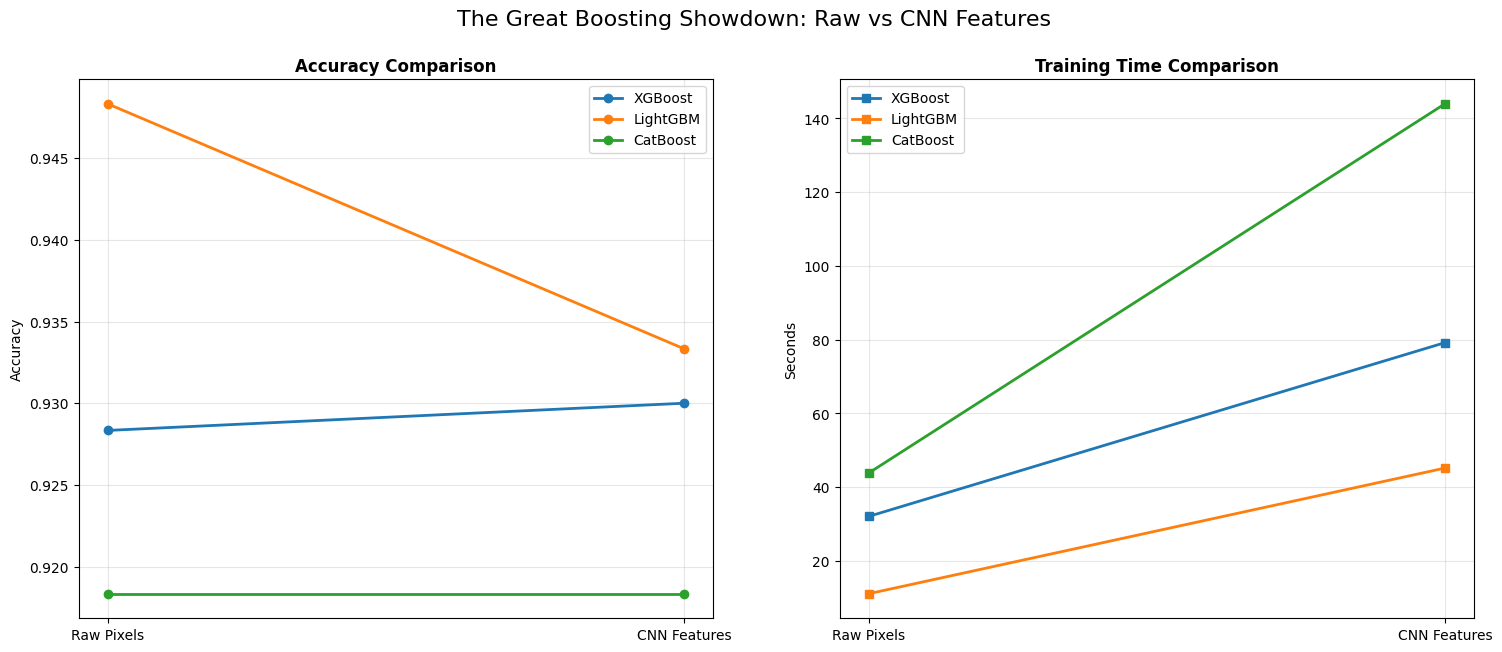

                  Acc                    Time           
Type     CNN Features Raw Pixels CNN Features Raw Pixels
Model                                                   
CatBoost     0.918333   0.918333   143.944512  43.773903
LightGBM     0.933333   0.948333    45.152036  11.062756
XGBoost      0.930000   0.928333    79.166922  32.026910


In [ ]:
# 1. Load MNIST Dataset
print("Loading MNIST data...")
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = tf.keras.datasets.mnist.load_data()

# Subset for a quick execution (e.g., 3000 samples)
subset_size = 3000
x_sub = x_train_orig[:subset_size]
y_sub = y_train_orig[:subset_size]

# --- METHOD A: Raw Pixel Vectorization ---
# Flatten 28x28 images into 784-element vectors and normalize
x_raw = x_sub.reshape(subset_size, -1) / 255.0
X_train_raw, X_test_raw, y_train, y_test = train_test_split(x_raw, y_sub, test_size=0.2, random_state=42)

# --- METHOD B: CNN Feature Extraction ---
print("Extracting CNN features using MobileNetV2...")
# Prepare images for MobileNetV2 (Resize to 96x96 and make it 3-channel RGB)
x_rgb = np.repeat(x_sub[..., np.newaxis], 3, -1)
x_rgb_resized = tf.image.resize(x_rgb, [96, 96]).numpy()
x_rgb_preprocessed = preprocess_input(x_rgb_resized)

# Feature extractor (pooling='avg' returns a 1280-dim vector)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3), pooling='avg')
x_cnn_features = base_model.predict(x_rgb_preprocessed, verbose=0)

X_train_cnn, X_test_cnn, _, _ = train_test_split(x_cnn_features, y_sub, test_size=0.2, random_state=42)

# 2. Performance Tracking Setup
results = []

def benchmark_models(X_train, X_test, y_train, y_test, data_type):
    # --- XGBoost ---
    print(f"[{data_type}] Training XGBoost...")
    start = time.time()
    m_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist')
    m_xgb.fit(X_train, y_train)
    results.append({'Model': 'XGBoost', 'Type': data_type, 'Acc': accuracy_score(y_test, m_xgb.predict(X_test)), 'Time': time.time() - start})

    # --- LightGBM ---
    print(f"[{data_type}] Training LightGBM...")
    start = time.time()
    m_lgb = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1)
    m_lgb.fit(X_train, y_train)
    results.append({'Model': 'LightGBM', 'Type': data_type, 'Acc': accuracy_score(y_test, m_lgb.predict(X_test)), 'Time': time.time() - start})

    # --- CatBoost ---
    print(f"[{data_type}] Training CatBoost...")
    start = time.time()
    m_cb = CatBoostClassifier(n_estimators=100, learning_rate=0.1, silent=True)
    m_cb.fit(X_train, y_train)
    results.append({'Model': 'CatBoost', 'Type': data_type, 'Acc': accuracy_score(y_test, m_cb.predict(X_test)), 'Time': time.time() - start})

# Execute benchmarks
benchmark_models(X_train_raw, X_test_raw, y_train, y_test, "Raw Pixels")
benchmark_models(X_train_cnn, X_test_cnn, y_train, y_test, "CNN Features")

# 3. Visualization
res_df = pd.DataFrame(results)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot Accuracy
for model in res_df['Model'].unique():
    subset = res_df[res_df['Model'] == model]
    ax1.plot(subset['Type'], subset['Acc'], marker='o', label=model, linewidth=2)
ax1.set_title('Accuracy Comparison', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot Training Time
for model in res_df['Model'].unique():
    subset = res_df[res_df['Model'] == model]
    ax2.plot(subset['Type'], subset['Time'], marker='s', label=model, linewidth=2)
ax2.set_title('Training Time Comparison', fontweight='bold')
ax2.set_ylabel('Seconds')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.suptitle('Raw vs CNN Features on different models', fontsize=16)
plt.show()

# Display table
print(res_df.pivot(index='Model', columns='Type', values=['Acc', 'Time']))

Performance of progressively rotated images
TO DO: add nn confront

Extracting CNN features for Training...
Testing rotation: 0 degrees...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing rotation: 15 degrees...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing rotation: 30 degrees...


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing rotation: 75 degrees...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Testing rotation: 90 degrees...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


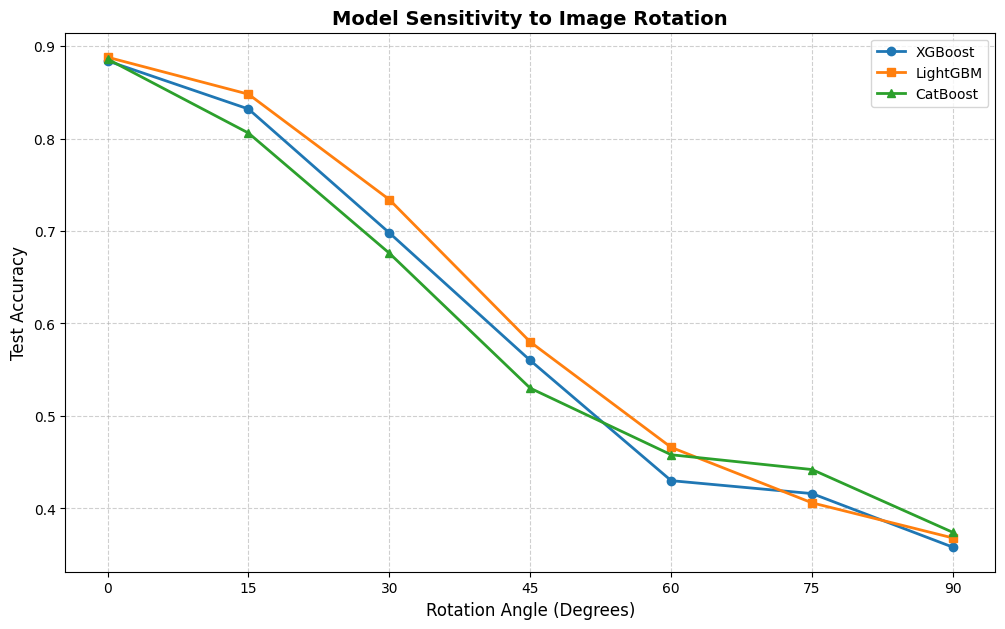

In [ ]:
# 1. Setup Data (MNIST)
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = tf.keras.datasets.mnist.load_data()
subset_size = 2000
x_train_sub, y_train = x_train_orig[:subset_size], y_train_orig[:subset_size]
x_test_sub, y_test = x_test_orig[:500], y_test_orig[:500] # Smaller test set for speed

# --- TRAIN MODELS ON CLEAN (NON-ROTATED) DATA ---
# We use CNN features for this test as they are generally more robust
print("Extracting CNN features for Training...")
def get_cnn_features(data):
    rgb = np.repeat(data[..., np.newaxis], 3, -1)
    resized = tf.image.resize(rgb, [96, 96]).numpy()
    preprocessed = preprocess_input(resized)
    model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96, 96, 3), pooling='avg')
    return model.predict(preprocessed, verbose=0)

X_train_cnn = get_cnn_features(x_train_sub)

# Initialize and train the three models
m_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist').fit(X_train_cnn, y_train)
m_lgb = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1).fit(X_train_cnn, y_train)
m_cb = CatBoostClassifier(n_estimators=100, learning_rate=0.1, silent=True).fit(X_train_cnn, y_train)

# --- PROGRESSIVE ROTATION TEST ---
angles = [0, 15, 30, 45, 60, 75, 90]
rotation_results = []

for angle in angles:
    print(f"Testing rotation: {angle} degrees...")

    # Rotate test images
    x_test_rotated = np.array([rotate(img, angle, reshape=False) for img in x_test_sub])

    # Extract features from rotated images
    X_test_rotated_cnn = get_cnn_features(x_test_rotated)

    # Predict
    acc_xgb = accuracy_score(y_test, m_xgb.predict(X_test_rotated_cnn))
    acc_lgb = accuracy_score(y_test, m_lgb.predict(X_test_rotated_cnn))
    acc_cb = accuracy_score(y_test, m_cb.predict(X_test_rotated_cnn))

    rotation_results.append({
        'Angle': angle,
        'XGBoost': acc_xgb,
        'LightGBM': acc_lgb,
        'CatBoost': acc_cb
    })

# 2. Plotting the Robustness Decay
res_df = pd.DataFrame(rotation_results)

plt.figure(figsize=(12, 7))
plt.plot(res_df['Angle'], res_df['XGBoost'], marker='o', label='XGBoost', linewidth=2)
plt.plot(res_df['Angle'], res_df['LightGBM'], marker='s', label='LightGBM', linewidth=2)
plt.plot(res_df['Angle'], res_df['CatBoost'], marker='^', label='CatBoost', linewidth=2)

plt.title('Model Sensitivity to Image Rotation', fontweight='bold', fontsize=14)
plt.xlabel('Rotation Angle (Degrees)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xticks(angles)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Performance on images variating the contrast of the image

TO DO : add NN

In [ ]:
# 1. Setup Data (MNIST) - Raw Pixels
print("Loading MNIST data...")
(x_train_orig, y_train_orig), (x_test_orig, y_test_orig) = tf.keras.datasets.mnist.load_data()

# Subset for speed
subset_size = 5000
test_size = 1000

# Flatten and normalize to [0, 1]
X_train = x_train_orig[:subset_size].reshape(subset_size, -1) / 255.0
y_train = y_train_orig[:subset_size]

X_test_base = x_test_orig[:test_size].reshape(test_size, -1) / 255.0
y_test = y_test_orig[:test_size]

# --- TRAIN MODELS ON CLEAN DATA ---
print("Training models on raw pixels...")

m_xgb = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, tree_method='hist').fit(X_train, y_train)
m_lgb = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, verbosity=-1).fit(X_train, y_train)
m_cb = CatBoostClassifier(n_estimators=100, learning_rate=0.1, silent=True).fit(X_train, y_train)

# --- RAW CONTRAST FUNCTION ---
def apply_raw_contrast(X, alpha):
    """
    X is assumed to be in [0, 1] range.
    Formula: I_new = mean + alpha * (I - mean)
    """
    X_cont = X.copy()
    for i in range(X_cont.shape[0]):
        img_mean = np.mean(X_cont[i])
        X_cont[i] = img_mean + alpha * (X_cont[i] - img_mean)
    return np.clip(X_cont, 0, 1)

# --- TESTING LOOP ---
contrast_levels = [0.1, 0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0]
results = []

for a in contrast_levels:
    print(f"Testing contrast alpha: {a}...")
    X_test_mod = apply_raw_contrast(X_test_base, a)

    acc_xgb = accuracy_score(y_test, m_xgb.predict(X_test_mod))
    acc_lgb = accuracy_score(y_test, m_lgb.predict(X_test_mod))
    acc_cb = accuracy_score(y_test, m_cb.predict(X_test_mod))

    results.append({'Alpha': a, 'XGBoost': acc_xgb, 'LightGBM': acc_lgb, 'CatBoost': acc_cb})

# 2. Visualization
res_df = pd.DataFrame(results)

plt.figure(figsize=(12, 7))
plt.plot(res_df['Alpha'], res_df['XGBoost'], marker='o', label='XGBoost', linewidth=2)
plt.plot(res_df['Alpha'], res_df['LightGBM'], marker='s', label='LightGBM', linewidth=2)
plt.plot(res_df['Alpha'], res_df['CatBoost'], marker='^', label='CatBoost', linewidth=2)

plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Baseline (Original)')
plt.title('Boosting Performance vs Raw Pixel Contrast', fontweight='bold', fontsize=14)
plt.xlabel('Contrast Factor (Alpha)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Loading MNIST data...


NameError: name 'tf' is not defined

## Performance on traslated features in the MNIST dataset

TO DO: add performance with plain cnn model

In [ ]:
(x_train_orig, y_train), (x_test_orig, y_test) = tf.keras.datasets.mnist.load_data()

def create_shifted_dataset(images, canvas_size=64, random_shift=True):
    dataset = np.zeros((len(images), canvas_size, canvas_size))
    coords = []
    for i, img in enumerate(images):
        if random_shift:
            h_off = np.random.randint(0, canvas_size - 28)
            v_off = np.random.randint(0, canvas_size - 28)
        else:
            h_off, v_off = (canvas_size-28)//2, (canvas_size-28)//2 # Centered

        dataset[i, v_off:v_off+28, h_off:h_off+28] = img
        coords.append([v_off / canvas_size, h_off / canvas_size]) # Normalized coords
    return dataset, np.array(coords)

# Create Training (Centered) and Testing (Randomly Shifted)
X_train_canvas, _ = create_shifted_dataset(x_train_orig[:5000], random_shift=False)
X_test_shifted, test_coords = create_shifted_dataset(x_test_orig[:1000], random_shift=True)

# Flatten for Boosted Models
X_train_flat = X_train_canvas.reshape(len(X_train_canvas), -1) / 255.0
X_test_flat = X_test_shifted.reshape(len(X_test_shifted), -1) / 255.0
y_train_sub = y_train[:5000]
y_test_sub = y_test[:1000]

In [ ]:
from tensorflow.keras import layers, models

# 2. CNN to Locate the Number
loc_model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='sigmoid') # Outputs [y_norm, x_norm]
])

loc_model.compile(optimizer='adam', loss='mse')

# Train it briefly to recognize positions
print("Training Localization CNN...")
X_train_loc, train_coords = create_shifted_dataset(x_train_orig[:2000], random_shift=True)
loc_model.fit(X_train_loc.reshape(-1, 64, 64, 1)/255.0, train_coords, epochs=5, verbose=0)

Training Localization CNN...


In [ ]:
# 2. CNN to Locate the Number
loc_model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),
    layers.Conv2D(16, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='sigmoid') # Outputs [y_norm, x_norm]
])

loc_model.compile(optimizer='adam', loss='mse')

# Train it briefly to recognize positions
print("Training Localization CNN...")
X_train_loc, train_coords = create_shifted_dataset(x_train_orig[:2000], random_shift=True)
loc_model.fit(X_train_loc.reshape(-1, 64, 64, 1)/255.0, train_coords, epochs=5, verbose=0)

Training Localization CNN...


In [ ]:
# 3. Train Boosted Models on CENTERED data
print("Training Boosted Models on Centered Data...")
m_xgb = xgb.XGBClassifier(n_estimators=50).fit(X_train_flat, y_train_sub)
m_lgb = lgb.LGBMClassifier(n_estimators=50, verbosity=-1).fit(X_train_flat, y_train_sub)
m_cb = CatBoostClassifier(n_estimators=50, silent=True).fit(X_train_flat, y_train_sub)

# 4. Evaluate on SHIFTED data
acc_xgb = accuracy_score(y_test_sub, m_xgb.predict(X_test_flat))
acc_lgb = accuracy_score(y_test_sub, m_lgb.predict(X_test_flat))
acc_cb = accuracy_score(y_test_sub, m_cb.predict(X_test_flat))

print(f"\n--- RESULTS ON SHIFTED DATA ---")
print(f"XGBoost Accuracy: {acc_xgb:.4f}")
print(f"LightGBM Accuracy: {acc_lgb:.4f}")
print(f"CatBoost Accuracy: {acc_cb:.4f}")

Training Boosted Models on Centered Data...

--- RESULTS ON SHIFTED DATA ---
XGBoost Accuracy: 0.1760
LightGBM Accuracy: 0.1110
CatBoost Accuracy: 0.1110


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


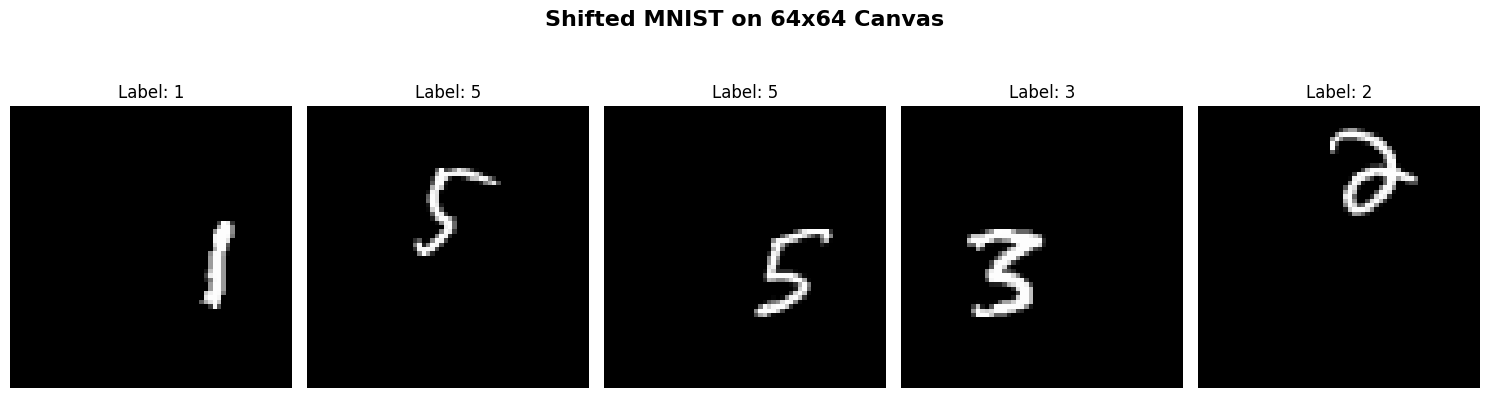

In [ ]:
import matplotlib.pyplot as plt

def plot_altered_samples(X_canvas, y_labels, n_samples=5):
    """
    Plots a row of images from the shifted 64x64 dataset.
    """
    plt.figure(figsize=(15, 4))
    for i in range(n_samples):
        # Pick a random index
        idx = np.random.randint(0, len(X_canvas))

        plt.subplot(1, n_samples, i + 1)
        # Reshape back to 64x64 if it was flattened
        img_display = X_canvas[idx].reshape(64, 64)

        plt.imshow(img_display, cmap='gray')
        plt.title(f"Label: {y_labels[idx]}")
        plt.axis('off')

    plt.suptitle("Shifted MNIST on 64x64 Canvas", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Execute the plot
plot_altered_samples(X_test_shifted, y_test_sub)

## Performance in the multiclassification case

TO DO: everything

## Performance on time-correlated data

TO DO: everything